# Axion PINN V3 — Comprehensive Improvements

## การปรับปรุงจาก V2 (แก้ปัญหา m=200 error 1200%)

### ปัญหาที่พบใน V2
| ปัญหา | สาเหตุ |
|---|---|
| L-BFGS diverge (loss เพิ่มขึ้น) | `max_iter=3000` ใน single call → overshoot |
| Adam loss ติด plateau ~10 | `causal_eps=10` ตั้งแต่แรก → gradient vanish เร็วเกินไป |
| a(t) แตกที่ late time | `a_net` ไม่มี pretrain → ค่าเริ่มต้นไม่ดี |
| φ(t) oscillations ไม่แม่น | Log-time features อย่างเดียวไม่พอสำหรับ fast oscillations |

### V3 Improvements

| Improvement | เทคนิค | ผลที่คาดหวัง |
|---|---|---|
| **1. Snake Activation** | `x + sin²(α·x)/α` learnable freq | จัดการ periodic solution ได้ดีกว่า |
| **2. Oscillatory Embedding** | `sin(k·m·t), cos(k·m·t)` features | Network เห็น fast oscillations โดยตรง |
| **3. a_net Pretraining** | Fit ODE reference `log(a(t))` | a(t) เริ่มต้นถูกต้อง ป้องกัน diverge |
| **4. Causal ε Warmup** | ε: 1.0 → 10.0 over 3000 epochs | หลีกเลี่ยง gradient vanish ระยะแรก |
| **5. LR Warmup** | Linear warmup + cosine decay | เสถียรกว่าเริ่ม Adam ตรงๆ |
| **6. Iterative L-BFGS** | Outer loop × small inner steps | ป้องกัน L-BFGS overshoot |
| **7. Enhanced Collocation** | 30% dense in oscillating region | Residuals ครอบคลุม oscillations |
| **8. Larger phi_net** | +n_harmonics +hidden +depth | Capacity เพียงพอสำหรับ rapid osc |
| **9. Bessel Embedding** | `j₀(kmt), y₀(kmt)` features | Inductive bias ตรงกับ exact solution |
| **10. VoP Ansatz** | φ = C₁(t)·j₀(mt) + C₂(t)·y₀(mt) | Network เรียนแค่ slow correction |

---

### ทำไม Bessel Functions ถูกต้องสำหรับงานนี้

ใน **matter domination** ($a \propto t^{2/3}$, $H = 2/(3t)$) Klein-Gordon กลายเป็น spherical Bessel equation (order 0):
$$\ddot\phi + \frac{2}{t}\dot\phi + m^2\phi = 0 \quad\Longleftrightarrow\quad x^2\frac{d^2\phi}{dx^2}+2x\frac{d\phi}{dx}+x^2\phi=0, \quad x=mt$$

**Exact solution**: $\phi(t) = \dfrac{C_1\sin(mt)+C_2\cos(mt)}{mt} = C_1 j_0(mt) + C_2 y_0(mt)$

- **BesselEmb**: ใช้ $j_0(kmt), y_0(kmt)$ เป็น input features แทน $\sin(kmt), \cos(kmt)$
  → Features มี $1/(kmt)$ decay built-in → network เรียนแค่ slowly-varying correction
- **VoPFieldNet**: ใช้ exact Bessel basis เป็น ansatz โดยตรง → correct structure guaranteed

## 1. Imports & Setup

In [1]:
import os, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE  = torch.float64
EPS    = 1e-20

print(f'Device: {DEVICE} | PyTorch: {torch.__version__}')

Device: cuda | PyTorch: 2.7.0+cu126


## 2. Physical Parameters

In [2]:
RHO_M0   = 0.81
RHO_R0   = 0.00027138
RHO_L0   = 2.19
A_IN     = 1e-8
T_IN     = 0.0
T_FI     = 1.0

_INV_SQRT3 = 3.0**(-0.5)
_SQRT3     = 3.0**( 0.5)
T_SCALE    = A_IN


def analyze_mass_regime(m_target: float, t_end: float = T_FI) -> dict:
    MAX_N_OSC = 500
    n_osc = m_target / (2 * np.pi) * t_end
    a_osc = (3 * RHO_R0 / m_target**2) ** 0.25

    if n_osc <= MAX_N_OSC:
        mode, m_sim, lam = 'direct', m_target, 1.0
        t_end_sim = t_end
    else:
        C     = 2 * np.pi * (MAX_N_OSC / 2) / t_end
        m_sim = max(100.0, (C * m_target**0.5) ** (2.0/3.0))
        lam   = np.sqrt(m_target / m_sim)
        mode  = 'rescaling'
        t_end_sim = t_end / lam

    regime = ('slow-roll'    if m_target < 3    else
               'onset'       if m_target < 50   else
               'oscillating' if m_target < 500  else 'rapid-osc')
    return dict(mode=mode, regime=regime, m_target=m_target, m_sim=m_sim,
                lam=lam, t_end=t_end, t_end_sim=t_end_sim,
                a_osc=a_osc, n_osc=n_osc)


def print_mass_summary(mc):
    print(f"{'─'*58}")
    print(f"  m_target={mc['m_target']:.3g}  regime={mc['regime']}  mode={mc['mode']}")
    print(f"  N_osc(physical)={mc['n_osc']:.2e}  |  a_osc={mc['a_osc']:.3e}")
    if mc['mode'] == 'rescaling':
        print(f"  m_sim={mc['m_sim']:.3g}  λ={mc['lam']:.3g}  t_end_sim={mc['t_end_sim']:.3e}")
    print(f"{'─'*58}")

## 3. ODE Reference Solver

In [3]:
def _one_axion_rhs(t, y, m2, rho_m0=RHO_M0, rho_r0=RHO_R0, rho_l0=RHO_L0):
    a, phi, phi_dot = y
    a_safe  = max(a, 1e-60)
    rho_ax  = 0.5 * phi_dot**2 + 0.5 * m2 * phi**2
    rho_tot = rho_ax + rho_m0/a_safe**3 + rho_r0/a_safe**4 + rho_l0
    sqrt_rho = np.sqrt(max(rho_tot, 0.0))
    return [a * (1.0/_SQRT3) * sqrt_rho,
            phi_dot,
            -_SQRT3 * sqrt_rho * phi_dot - m2 * phi]


def solve_ode(m_sim, phi0, phi_dot0=0.0, a0=A_IN, t_end_sim=T_FI,
              rho_m0=RHO_M0, rho_r0=RHO_R0, rho_l0=RHO_L0,
              n_points=10000) -> dict:
    m2 = m_sim**2
    t0_safe = max(a0, 1e-13)
    t_eval  = np.logspace(np.log10(t0_safe), np.log10(t_end_sim), n_points)
    t_start = time.time()
    sol = solve_ivp(
        lambda t, y: _one_axion_rhs(t, y, m2, rho_m0, rho_r0, rho_l0),
        [t_eval[0], t_eval[-1]], [a0, phi0, phi_dot0],
        t_eval=t_eval, method='DOP853', rtol=1e-11, atol=1e-13)
    elapsed = time.time() - t_start
    print(f'ODE: {elapsed:.2f}s  success={sol.success}  nfev={sol.nfev}')
    a, phi, phi_dot = sol.y
    rho_ax  = 0.5 * phi_dot**2 + 0.5 * m2 * phi**2
    rho_tot = rho_ax + rho_m0/a**3 + rho_r0/a**4 + rho_l0
    H = np.sqrt(rho_tot / 3.0)
    return dict(t=sol.t, a=a, phi=phi, phi_dot=phi_dot,
                rho_ax=rho_ax, H=H)


print('ODE solver loaded.')

ODE solver loaded.


## 4. V3 NEW: Activations — Snake + SnakeBlock

**Snake activation** (Ziyin et al., NeurIPS 2020):
$$f(x) = x + \frac{\sin^2(\alpha x)}{\alpha}$$

- $\alpha$ เป็น learnable parameter แต่ละ neuron
- เหมาะกับ periodic/oscillating solutions เพราะมีทั้ง linear path (`x`) และ periodic correction
- ต่างจาก SIREN (pure `sin`) ตรงที่ gradient ไม่ vanish เร็ว
- สำหรับ $\alpha \to 0$: $f(x) \to x$ (ปลอดภัย → ไม่ explode)
- สำหรับ $\alpha$ ใหญ่: เพิ่ม oscillatory component

In [4]:
# ── V3 IMPROVEMENT 1: Snake Activation ───────────────────────────────────────

class Snake(nn.Module):
    """
    Snake activation: f(x) = x + sin²(α·x) / α

    Learnable per-neuron frequency α. Unlike SIREN's pure sin(),
    Snake retains the identity path x → easier gradient flow.

    Reference: Ziyin et al. (2020) NeurIPS — 'Neural networks fail to
    learn periodic functions and how to fix it'
    """
    def __init__(self, width: int, init_freq: float = 1.0, dtype=torch.float64):
        super().__init__()
        self.alpha = nn.Parameter(
            torch.ones(width, dtype=dtype) * float(init_freq))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        a = self.alpha.abs() + 1e-8   # strictly positive
        return x + torch.sin(a * x)**2 / a


class SnakeBlock(nn.Module):
    """
    Residual block: output = x + fc2( snake( fc1(x) ) )
    Replaces V2's SinResBlock for oscillating solutions.
    """
    def __init__(self, width: int, init_freq: float = 1.0, dtype=torch.float64):
        super().__init__()
        self.fc1 = nn.Linear(width, width, dtype=dtype)
        self.act = Snake(width, init_freq=init_freq, dtype=dtype)
        self.fc2 = nn.Linear(width, width, dtype=dtype)
        nn.init.uniform_(self.fc1.weight, -np.sqrt(6/width), np.sqrt(6/width))
        nn.init.zeros_(self.fc1.bias)
        nn.init.uniform_(self.fc2.weight, -np.sqrt(6/width), np.sqrt(6/width))
        nn.init.zeros_(self.fc2.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.fc2(self.act(self.fc1(x)))


# Keep V2's SinResBlock for ScaleFactorNet (a_net doesn't oscillate)
class SinResBlock(nn.Module):
    """SIREN-style residual block (used for a_net)."""
    def __init__(self, width: int, dtype=torch.float64):
        super().__init__()
        self.fc1 = nn.Linear(width, width, dtype=dtype)
        self.fc2 = nn.Linear(width, width, dtype=dtype)
        nn.init.uniform_(self.fc1.weight, -np.sqrt(6/width), np.sqrt(6/width))
        nn.init.uniform_(self.fc2.weight, -np.sqrt(6/width), np.sqrt(6/width))

    def forward(self, x):
        return x + self.fc2(torch.sin(self.fc1(x)))


print('Snake / SnakeBlock / SinResBlock loaded.')

Snake / SnakeBlock / SinResBlock loaded.


## 5. V3 Embeddings — Oscillatory, Bessel, LogTimeFourier

| Embedding | Features | เหมาะกับ |
|---|---|---|
| `LogTimeFourierEmb` | Fourier ใน τ=log(1+t/t_scale) | Slow envelope A(t), a(t) |
| `OscillatoryEmb` | sin(kmt), cos(kmt) | Fast oscillations (generic) |
| `BesselEmb(order='zero')` | j₀(kmt)=sin(kmt)/(kmt), y₀=-cos/(kmt) | VoP matter-dom approx |
| **`BesselEmb(order='half')`** | J₁/₂(kmt)=sin(kmt)/√(kmt), Y₁/₂=-cos/√(kmt) | **Exact solution formula** |

### Derive ทำไม `order='half'` ถูกต้อง

จาก exact solution $\phi = a^{-3/2}(t/t_i)^{1/2}[C_1 J_n(m_a t) + C_2 Y_n(m_a t)]$:

**Matter domination** ($a \propto t^{2/3}$): แทน $\phi = t^{-1/2} f(mt)$ ลงใน KG:
$$f''(x) + \left(1 - \frac{n^2}{x^2}\right)f = 0, \quad n = \frac{1}{2}, \quad x = mt$$

$J_{1/2}(x) = \sqrt{\dfrac{2}{\pi x}}\sin x$, $\quad Y_{1/2}(x) = -\sqrt{\dfrac{2}{\pi x}}\cos x$ — **analytic, no scipy needed**

**Verify prefactor ใน matter dom:**  $a^{-3/2} \propto t^{-1}$, $(t/t_i)^{1/2} \propto t^{1/2}$, $J_{1/2}(mt) \propto t^{-1/2}\sin(mt)$
$$\Rightarrow \phi \propto t^{-1} \cdot t^{1/2} \cdot t^{-1/2}\sin(mt) = \frac{\sin(mt)}{t} \quad \checkmark$$

ตรงกับ $j_0(mt) = \sin(mt)/(mt)$ พอดี (up to constant $m$)

In [5]:
# ── V3 IMPROVEMENT 2: Oscillatory Embedding ──────────────────────────────────

class OscillatoryEmb(nn.Module):
    """
    Fast oscillatory features: [sin(kmt), cos(kmt)] for k=1..K
    """
    def __init__(self, m_sim: float, n_harmonics: int = 4, dtype=torch.float64):
        super().__init__()
        freqs = torch.arange(1, n_harmonics + 1, dtype=dtype) * float(m_sim)
        self.register_buffer('freqs', freqs)
        self.out_dim = 2 * n_harmonics

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        phases = t * self.freqs.unsqueeze(0)
        return torch.cat([torch.sin(phases), torch.cos(phases)], dim=-1)


# ── V3 NEW (Improvement 9): Bessel Embedding — two modes ─────────────────────

class BesselEmb(nn.Module):
    """
    Spherical/Regular Bessel features for k=1..K:

    order='zero'  (spherical):
        j0(kmt) = sin(kmt) / (kmt)          — exact solution in pure matter dom
        y0(kmt) = -cos(kmt) / (kmt)

    order='half'  (regular, J_{1/2}):  ← CORRECT for exact formula
        J_{1/2}(kmt) = sin(kmt) / sqrt(kmt) — matches a^{-3/2}(t/t_i)^{1/2} prefix
        Y_{1/2}(kmt) = -cos(kmt) / sqrt(kmt)

    WHY 'half' is CORRECT:
    -----------------------
    The exact axion solution is: φ = a^{-3/2}(t/t_i)^{1/2} [C1 J_{1/2}(mt) + C2 Y_{1/2}(mt)]

    Substituting φ = t^{-1/2} f(x), x=mt into KG in matter dom gives Bessel eq with n=1/2.
    J_{1/2} and Y_{1/2} are analytic → no scipy required.

    Verify (matter dom): a^{-3/2} ~ t^{-1}, (t/ti)^{1/2} ~ t^{1/2}, J_{1/2} ~ t^{-1/2} sin
        → φ ~ t^{-1}·t^{1/2}·t^{-1/2} sin(mt) = sin(mt)/t  ✓  (matches j0 up to const m)
    """
    def __init__(self, m_sim: float, n_orders: int = 4,
                 order: str = 'half', dtype=torch.float64):
        super().__init__()
        assert order in ('zero', 'half'), \
            f"order must be 'zero' or 'half', got {order!r}"
        ks = torch.arange(1, n_orders + 1, dtype=dtype) * float(m_sim)
        self.register_buffer('freqs', ks)
        self.order   = order
        self.out_dim = 2 * n_orders

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        t_safe = t.clamp(min=1e-30)
        x = t_safe * self.freqs.unsqueeze(0)   # (N, K), x = k·m·t
        if self.order == 'zero':
            # Spherical Bessel: j0 = sin/x, y0 = -cos/x
            j = torch.sin(x) / x
            y = -torch.cos(x) / x
        else:
            # Regular Bessel n=1/2: J_{1/2} = sin/sqrt(x), Y_{1/2} = -cos/sqrt(x)
            sqrt_x = torch.sqrt(x)
            j = torch.sin(x) / sqrt_x
            y = -torch.cos(x) / sqrt_x
        return torch.cat([j, y], dim=-1)        # (N, 2K)


class LogTimeFourierEmb(nn.Module):
    """
    Multi-scale Fourier embedding on log-time τ = log(1 + t/t_scale).
    Handles slow envelope A(t), a(t).
    """
    def __init__(self, n_per_band: int, n_bands: int, m_sim: float,
                 t_scale: float = T_SCALE, dtype=torch.float64):
        super().__init__()
        self.t_scale = float(t_scale)
        n_bands  = max(2, n_bands)
        tau_max  = np.log1p(1.0 / t_scale)
        log_lo   = np.log(1.0 / tau_max)
        log_hi   = np.log(max(m_sim, 1.0))
        log_inits = np.linspace(log_lo, log_hi, n_bands)
        self.log_scales = nn.Parameter(
            torch.tensor(log_inits, dtype=dtype))
        B = torch.randn(n_bands, n_per_band, 1, dtype=dtype)
        self.register_buffer('B', B)
        self.n_bands    = n_bands
        self.n_per_band = n_per_band
        self.out_dim    = n_bands * 2 * n_per_band

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        tau    = torch.log1p(t / self.t_scale)
        scales = torch.exp(self.log_scales)
        parts  = []
        for b in range(self.n_bands):
            proj = 2.0 * np.pi * scales[b] * (tau @ self.B[b].T)
            parts.append(torch.sin(proj))
            parts.append(torch.cos(proj))
        return torch.cat(parts, dim=-1)


# ── Quick sanity checks ───────────────────────────────────────────────────────
_t_test = torch.tensor([[0.1]], dtype=torch.float64)
_m = 200.0
_b0 = BesselEmb(_m, n_orders=2, order='zero')
_bh = BesselEmb(_m, n_orders=2, order='half')
_f0 = _b0(_t_test)
_fh = _bh(_t_test)
x = _m * 0.1  # = 20
print(f"BesselEmb (order='zero')  j0(mt)={_f0[0,0]:.4f}  expect sin({x:.0f})/{x:.0f}={np.sin(x)/x:.4f}")
print(f"BesselEmb (order='half')  J_(mt)={_fh[0,0]:.4f}  expect sin({x:.0f})/sqrt({x:.0f})={np.sin(x)/np.sqrt(x):.4f}")
print("BesselEmb + OscillatoryEmb + LogTimeFourierEmb loaded.")

BesselEmb (order='zero')  j0(mt)=0.0456  expect sin(20)/20=0.0456
BesselEmb (order='half')  J_(mt)=0.2041  expect sin(20)/sqrt(20)=0.2041
BesselEmb + OscillatoryEmb + LogTimeFourierEmb loaded.


## 6. V3 Network Architectures

| Network | Ansatz | Note |
|---|---|---|
| `ScaleFactorNet` | $a = a_0 e^{\tau\,\text{sp}(\text{net})}$ | Same as V2 |
| `WKBFieldNet_V3` | $\phi = A(t)\cos(mt+\delta\Phi)$ | emb_type: bessel/oscil/both |
| `VoPFieldNet_V3` | $\phi = C_1 j_0(mt) + C_2 y_0(mt)$ | Approx (matter dom only) |
| **`ExactVoPFieldNet_V3`** | $\phi = a^{-3/2}(t/t_i)^{1/2}[C_1 J_{1/2} + C_2 Y_{1/2}]$ | **Exact formula** |

### ExactVoPPINN — Architecture

```
t ──→ a_net ──→ a(t)              [ScaleFactorNet, trained by Friedmann]
         │                         └── detach()
         └──→ a_detached ──┐
t ──────────────────────→ ExactVoPFieldNet_V3  →  φ(t)
                             = a_det^{-3/2}·(t/tᵢ)^{1/2}·[C₁J_{1/2}(mt)+C₂Y_{1/2}(mt)]
```

**เหตุที่ detach() `a`**: ตัด gradient path จาก KG loss → a_net parameters (ไม่งั้น phi network จะรบกวน a_net ที่ train จาก Friedmann)

### Hard ICs for ExactVoPFieldNet_V3

$$C_1(t) = \phi_0 + \dot\phi_0 t + t^2 C_{1,\text{net}}, \quad C_2(t) = t^3 C_{2,\text{net}}$$

Verify ที่ $t \to 0$ (ใช้ $t_i > 0$ เล็กๆ เช่น $t_i = A_{in} = 10^{-8}$):
- $a(0) = a_0$, $a^{-3/2}(0) = a_0^{-3/2}$
- $J_{1/2}(0^+) \to 0$, $Y_{1/2}(0^+) \to 0$ → ต้องการ IC ผ่าน $C_1$ เท่านั้น
- $\phi(0) = a_0^{-3/2} \cdot 0 \cdot [C_1(0) \cdot 0 + ...] = 0$ ← ปัญหา!

**แก้**: normalize ออก prefix ที่ $t=0$ ออกก่อน:
$$\phi(t) = \frac{a(t)^{-3/2}(t/t_i)^{1/2}}{a_0^{-3/2}(t_{\epsilon}/t_i)^{1/2}} \cdot \left[C_1 J_{1/2}(mt) - C_{\text{IC}} J_{1/2}(mt_\epsilon)\right] + \phi_\text{IC hard}$$

หรือง่ายกว่า: **ใช้ additive decomposition**
$$\phi(t) = a^{-3/2}(t/t_i)^{1/2}[C_1(t) J_{1/2}(mt) + C_2(t) Y_{1/2}(mt)] + \phi_{\text{IC}}(t)$$
โดย $\phi_{\text{IC}}(t) = (\phi_0 - \phi_{\text{ref}}(0)) + \dot\phi_0 t$ เป็น hard IC correction

In [6]:
# ── ScaleFactorNet (unchanged from V2) ───────────────────────────────────────

class ScaleFactorNet(nn.Module):
    """
    a(t) = a0 * exp( τ · softplus(net(τ)) )  where τ = log(1+t/t_scale)
    Hard IC: a(0)=a0, monotone expansion.
    """
    def __init__(self, a0: float, n_per_band: int = 16, n_bands: int = 3,
                 hidden: int = 64, depth: int = 3,
                 t_scale: float = T_SCALE, dtype=torch.float64):
        super().__init__()
        self.emb = LogTimeFourierEmb(n_per_band, n_bands, m_sim=5.0,
                                      t_scale=t_scale, dtype=dtype)
        D = self.emb.out_dim
        layers = [nn.Linear(D, hidden, dtype=dtype), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden, dtype=dtype), nn.Tanh()]
        layers.append(nn.Linear(hidden, 1, dtype=dtype))
        self.net = nn.Sequential(*layers)
        self.sp  = nn.Softplus()
        self.register_buffer('a0', torch.tensor([[a0]], dtype=dtype))
        self.t_scale = float(t_scale)

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        tau = torch.log1p(t / self.t_scale)
        return self.a0 * torch.exp(tau * self.sp(self.net(self.emb(t))))


# ── WKBFieldNet_V3: WKB + Selectable Embedding ───────────────────────────────

class WKBFieldNet_V3(nn.Module):
    """
    WKB ansatz: φ(t) = A(t)·cos(m·t + δΦ(t))

    emb_type: 'oscil' | 'bessel' | 'both'
    For 'bessel': uses BesselEmb(order='half') — J_{1/2}, Y_{1/2}
    """
    def __init__(self, phi0: float, phi_dot0: float = 0.0,
                 m_sim: float = 100.0,
                 n_per_band: int = 20, n_bands: int = 5,
                 n_fast: int = 4,
                 hidden: int = 192, depth: int = 4,
                 emb_type: str = 'bessel',
                 t_scale: float = T_SCALE, dtype=torch.float64):
        super().__init__()
        self.m_sim    = float(m_sim)
        self.t_scale  = float(t_scale)
        self.emb_type = emb_type
        self.register_buffer('phi0',     torch.tensor([[float(phi0)]],     dtype=dtype))
        self.register_buffer('phi_dot0', torch.tensor([[float(phi_dot0)]], dtype=dtype))

        m_slow = max(1.0, m_sim ** 0.4)
        self.slow_emb = LogTimeFourierEmb(n_per_band, n_bands, m_slow, t_scale, dtype)

        if emb_type == 'oscil':
            self.fast_emb = OscillatoryEmb(m_sim, n_fast, dtype)
        elif emb_type == 'bessel':
            self.fast_emb = BesselEmb(m_sim, n_fast, order='half', dtype=dtype)
        elif emb_type == 'both':
            self._fast_oscil  = OscillatoryEmb(m_sim, n_fast, dtype)
            self._fast_bessel = BesselEmb(m_sim, n_fast, order='half', dtype=dtype)
            self.fast_emb = None
        else:
            raise ValueError(f"emb_type must be 'oscil', 'bessel', or 'both'")

        if emb_type == 'both':
            D = self.slow_emb.out_dim + self._fast_oscil.out_dim + self._fast_bessel.out_dim
        else:
            D = self.slow_emb.out_dim + self.fast_emb.out_dim

        self.input_proj = nn.Linear(D, hidden, dtype=dtype)
        self.blocks = nn.ModuleList([
            SnakeBlock(hidden, init_freq=max(0.3, 1.0 * (0.6**i)), dtype=dtype)
            for i in range(depth)
        ])
        self.head_A    = nn.Linear(hidden, 1, dtype=dtype)
        self.head_dPhi = nn.Linear(hidden, 1, dtype=dtype)
        nn.init.normal_(self.head_A.weight,    std=1e-3)
        nn.init.zeros_(self.head_A.bias)
        nn.init.normal_(self.head_dPhi.weight, std=1e-3)
        nn.init.zeros_(self.head_dPhi.bias)

    def _features(self, t: torch.Tensor) -> torch.Tensor:
        slow = self.slow_emb(t)
        if self.emb_type == 'both':
            return torch.cat([slow, self._fast_oscil(t), self._fast_bessel(t)], dim=-1)
        return torch.cat([slow, self.fast_emb(t)], dim=-1)

    def get_envelope_phase(self, t: torch.Tensor):
        h = self.input_proj(self._features(t))
        for block in self.blocks:
            h = block(h)
        A_raw    = self.head_A(h)
        dPhi_raw = self.head_dPhi(h)
        A    = self.phi0 + self.phi_dot0 * t + t**2 * A_raw
        dPhi = t * dPhi_raw
        return A, dPhi

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        A, dPhi = self.get_envelope_phase(t)
        return A * torch.cos(self.m_sim * t + dPhi)


# ── VoPFieldNet_V3: Approximate VoP (j0/y0, no a^{-3/2} prefix) ─────────────

class VoPFieldNet_V3(nn.Module):
    """
    Approximate VoP: φ(t) = C1(t)·j0(mt) + C2(t)·y0(mt)
    Hard ICs: C1(0)=phi0, C2(0)=0 via polynomial envelope.
    Valid for pure matter domination. Use ExactVoPFieldNet_V3 for full problem.
    """
    def __init__(self, phi0: float, phi_dot0: float = 0.0,
                 m_sim: float = 100.0,
                 n_per_band: int = 20, n_bands: int = 5,
                 n_bessel: int = 3,
                 hidden: int = 128, depth: int = 3,
                 t_scale: float = T_SCALE, dtype=torch.float64):
        super().__init__()
        self.m_sim   = float(m_sim)
        self.t_scale = float(t_scale)
        self.register_buffer('phi0',     torch.tensor([[float(phi0)]],     dtype=dtype))
        self.register_buffer('phi_dot0', torch.tensor([[float(phi_dot0)]], dtype=dtype))
        self.register_buffer('m_buf',    torch.tensor([[float(m_sim)]],    dtype=dtype))

        m_slow = max(1.0, m_sim ** 0.4)
        self.slow_emb   = LogTimeFourierEmb(n_per_band, n_bands, m_slow, t_scale, dtype)
        self.bessel_emb = BesselEmb(m_sim, n_bessel, order='zero', dtype=dtype)
        D = self.slow_emb.out_dim + self.bessel_emb.out_dim

        self.input_proj = nn.Linear(D, hidden, dtype=dtype)
        self.blocks = nn.ModuleList([
            SnakeBlock(hidden, init_freq=max(0.5, 0.8**i), dtype=dtype)
            for i in range(depth)
        ])
        self.head_C1 = nn.Linear(hidden, 1, dtype=dtype)
        self.head_C2 = nn.Linear(hidden, 1, dtype=dtype)
        nn.init.normal_(self.head_C1.weight, std=1e-3)
        nn.init.zeros_(self.head_C1.bias)
        nn.init.normal_(self.head_C2.weight, std=1e-3)
        nn.init.zeros_(self.head_C2.bias)

    def get_coefficients(self, t: torch.Tensor):
        feats = torch.cat([self.slow_emb(t), self.bessel_emb(t)], dim=-1)
        h = self.input_proj(feats)
        for block in self.blocks:
            h = block(h)
        C1 = self.phi0 + self.phi_dot0 * t + t**2 * self.head_C1(h)
        C2 = t**3 * self.head_C2(h)
        return C1, C2

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        C1, C2 = self.get_coefficients(t)
        t_safe = t.clamp(min=1e-30)
        mt     = self.m_buf * t_safe
        return C1 * (torch.sin(mt) / mt) + C2 * (-torch.cos(mt) / mt)


# ── V3 NEW (Improvement 10): ExactVoPFieldNet_V3 ─────────────────────────────

class ExactVoPFieldNet_V3(nn.Module):
    """
    Exact Variation of Parameters ansatz matching the image formula:

        φ(t) = a(t)^{-3/2} · (t/t_i)^{1/2} · [C1(t)·J_{1/2}(mt) + C2(t)·Y_{1/2}(mt)]

    where:
        J_{1/2}(x) = sin(x) / sqrt(x)   ← analytic, correct Bessel order for matter dom
        Y_{1/2}(x) = -cos(x) / sqrt(x)

    `a` is NOT stored here — it is provided by ExactVoPPINN.forward() from a_net.
    This ensures: (1) correct physics, (2) no gradient leakage from phi→a_net.

    Hard IC enforcement (additive decomposition):
        φ(t) = prefix(t,a) · [C1·J + C2·Y]  +  phi0  +  phi_dot0·t
                                                └── hard IC correction

    where C1(t) = t^2 · C1_net(features),  C2(t) = t^3 · C2_net(features)
    so the Bessel part vanishes at t→0 and the hard IC terms dominate.
    """
    def __init__(self, phi0: float, phi_dot0: float = 0.0,
                 m_sim: float = 100.0,
                 n_per_band: int = 20, n_bands: int = 5,
                 n_bessel: int = 3,
                 hidden: int = 128, depth: int = 3,
                 t_i: float = A_IN,          # initial time t_i (= a_in ≈ t_in)
                 t_scale: float = T_SCALE, dtype=torch.float64):
        super().__init__()
        self.m_sim   = float(m_sim)
        self.t_scale = float(t_scale)
        self.register_buffer('phi0',     torch.tensor([[float(phi0)]],     dtype=dtype))
        self.register_buffer('phi_dot0', torch.tensor([[float(phi_dot0)]], dtype=dtype))
        self.register_buffer('m_buf',    torch.tensor([[float(m_sim)]],    dtype=dtype))
        self.register_buffer('t_i',      torch.tensor([[float(t_i)]],      dtype=dtype))

        m_slow = max(1.0, m_sim ** 0.4)
        self.slow_emb   = LogTimeFourierEmb(n_per_band, n_bands, m_slow, t_scale, dtype)
        self.bessel_emb = BesselEmb(m_sim, n_bessel, order='half', dtype=dtype)
        D = self.slow_emb.out_dim + self.bessel_emb.out_dim

        self.input_proj = nn.Linear(D, hidden, dtype=dtype)
        self.blocks = nn.ModuleList([
            SnakeBlock(hidden, init_freq=max(0.5, 0.8**i), dtype=dtype)
            for i in range(depth)
        ])
        self.head_C1 = nn.Linear(hidden, 1, dtype=dtype)
        self.head_C2 = nn.Linear(hidden, 1, dtype=dtype)
        nn.init.normal_(self.head_C1.weight, std=1e-3)
        nn.init.zeros_(self.head_C1.bias)
        nn.init.normal_(self.head_C2.weight, std=1e-3)
        nn.init.zeros_(self.head_C2.bias)

    def _prefix(self, t: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
        """Exact prefactor: a^{-3/2} * sqrt(t/t_i)."""
        t_safe = t.clamp(min=1e-30)
        a_safe = a.clamp(min=EPS)
        return a_safe**(-1.5) * torch.sqrt(t_safe / self.t_i)

    def forward_with_a(self, t: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
        """Compute φ(t) given a(t) from a_net (a should be .detach()-ed)."""
        feats = torch.cat([self.slow_emb(t), self.bessel_emb(t)], dim=-1)
        h = self.input_proj(feats)
        for block in self.blocks:
            h = block(h)

        # Correction coefficients vanish at t=0 (t^2, t^3 factors)
        C1 = t**2 * self.head_C1(h)
        C2 = t**3 * self.head_C2(h)

        # Bessel basis J_{1/2}, Y_{1/2}
        t_safe = t.clamp(min=1e-30)
        mt     = self.m_buf * t_safe
        sqrt_mt = torch.sqrt(mt)
        J_half  = torch.sin(mt) / sqrt_mt
        Y_half  = -torch.cos(mt) / sqrt_mt

        # Full solution = exact prefactor × Bessel part + hard IC
        prefix = self._prefix(t, a)
        phi_bessel = prefix * (C1 * J_half + C2 * Y_half)

        # Hard IC: phi(0)=phi0, phi_dot(0)=phi_dot0
        # (phi_bessel → 0 as t→0 so hard IC terms dominate at early time)
        phi = phi_bessel + self.phi0 + self.phi_dot0 * t
        return phi


# ── ExactVoPPINN: chains a_net → ExactVoPFieldNet_V3 ─────────────────────────

class ExactVoPPINN(nn.Module):
    """
    PINN implementing the exact Bessel solution:

        a_net(t)  → Friedmann equation
        phi_net(t, a_detached) → Klein-Gordon with exact VoP ansatz

    Matches the image formula: φ = a^{-3/2}(t/t_i)^{1/2}[C₁J_{1/2} + C₂Y_{1/2}]

    The `.detach()` on `a` prevents gradient from KG loss from affecting a_net,
    keeping the two training signals clean. a_net is updated by Friedmann only.
    """
    def __init__(self, a_net: ScaleFactorNet, phi_net: ExactVoPFieldNet_V3):
        super().__init__()
        self.a_net   = a_net
        self.phi_net = phi_net

    def forward(self, t: torch.Tensor):
        a   = self.a_net(t)
        phi = self.phi_net.forward_with_a(t, a.detach())
        return a, phi


# ── FullICFieldNet_V3 (for sequential/window) ─────────────────────────────────

class FullICFieldNet_V3(nn.Module):
    """Hard IC: φ(t) = phi0 + phi_dot0·t + t²·net(features). With BesselEmb."""
    def __init__(self, phi0: float, phi_dot0: float = 0.0,
                 m_sim: float = 100.0,
                 n_per_band: int = 20, n_bands: int = 5,
                 n_fast: int = 4,
                 hidden: int = 192, depth: int = 4,
                 emb_type: str = 'bessel',
                 t_scale: float = T_SCALE, dtype=torch.float64):
        super().__init__()
        self.register_buffer('phi0',     torch.tensor([[float(phi0)]],     dtype=dtype))
        self.register_buffer('phi_dot0', torch.tensor([[float(phi_dot0)]], dtype=dtype))

        self.slow_emb = LogTimeFourierEmb(n_per_band, n_bands, m_sim, t_scale, dtype)
        self.has_fast = (n_fast > 0 and m_sim > 10.0)
        if self.has_fast:
            if emb_type == 'bessel':
                self.fast_emb = BesselEmb(m_sim, n_fast, order='half', dtype=dtype)
            else:
                self.fast_emb = OscillatoryEmb(m_sim, n_fast, dtype)
            D = self.slow_emb.out_dim + self.fast_emb.out_dim
        else:
            D = self.slow_emb.out_dim

        self.input_proj = nn.Linear(D, hidden, dtype=dtype)
        self.blocks = nn.ModuleList([
            SnakeBlock(hidden, init_freq=max(0.3, 1.0 * (0.6**i)), dtype=dtype)
            for i in range(depth)
        ])
        self.head = nn.Linear(hidden, 1, dtype=dtype)
        nn.init.normal_(self.head.weight, std=1e-3)
        nn.init.zeros_(self.head.bias)

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        feats = self.slow_emb(t)
        if self.has_fast:
            feats = torch.cat([feats, self.fast_emb(t)], dim=-1)
        h = self.input_proj(feats)
        for block in self.blocks:
            h = block(h)
        return self.phi0 + self.phi_dot0 * t + t**2 * self.head(h)


# ── GeneralPINN (WKB / VoP approximate) ──────────────────────────────────────

class GeneralPINN(nn.Module):
    """Standard container. Does NOT use exact a^{-3/2} prefix. Use ExactVoPPINN for that."""
    def __init__(self, a_net: ScaleFactorNet, phi_net):
        super().__init__()
        self.a_net   = a_net
        self.phi_net = phi_net

    def forward(self, t: torch.Tensor):
        return self.a_net(t), self.phi_net(t)


# ── Factories ─────────────────────────────────────────────────────────────────

def build_wkb_pinn_v3(mc: dict, phi0: float, phi_dot0: float = 0.0,
                       a0: float = A_IN,
                       n_per_band_a: int = 16, n_per_band_phi: int = 24,
                       n_bands_a: int = 3,    n_bands_phi: int = 5,
                       n_fast: int = 4,
                       hidden_a: int = 64,    hidden_phi: int = 192,
                       depth_a: int = 3,      depth_phi: int = 4,
                       emb_type: str = 'bessel',
                       dtype=torch.float64) -> GeneralPINN:
    a_net   = ScaleFactorNet(a0, n_per_band_a, n_bands_a, hidden_a, depth_a, dtype=dtype)
    phi_net = WKBFieldNet_V3(phi0, phi_dot0, mc['m_sim'],
                              n_per_band_phi, n_bands_phi, n_fast,
                              hidden_phi, depth_phi,
                              emb_type=emb_type, dtype=dtype)
    return GeneralPINN(a_net, phi_net)


def build_vop_pinn_v3(mc: dict, phi0: float, phi_dot0: float = 0.0,
                       a0: float = A_IN,
                       n_per_band_a: int = 16, n_per_band_phi: int = 20,
                       n_bands_a: int = 3,    n_bands_phi: int = 5,
                       n_bessel: int = 3,
                       hidden_a: int = 64,    hidden_phi: int = 128,
                       depth_a: int = 3,      depth_phi: int = 3,
                       dtype=torch.float64) -> GeneralPINN:
    """Approximate VoP (j0/y0 only, no a^{-3/2} prefix)."""
    a_net   = ScaleFactorNet(a0, n_per_band_a, n_bands_a, hidden_a, depth_a, dtype=dtype)
    phi_net = VoPFieldNet_V3(phi0, phi_dot0, mc['m_sim'],
                              n_per_band_phi, n_bands_phi, n_bessel,
                              hidden_phi, depth_phi, dtype=dtype)
    return GeneralPINN(a_net, phi_net)


def build_exact_vop_pinn_v3(mc: dict, phi0: float, phi_dot0: float = 0.0,
                              a0: float = A_IN,
                              n_per_band_a: int = 16, n_per_band_phi: int = 20,
                              n_bands_a: int = 3,    n_bands_phi: int = 5,
                              n_bessel: int = 3,
                              hidden_a: int = 64,    hidden_phi: int = 128,
                              depth_a: int = 3,      depth_phi: int = 3,
                              dtype=torch.float64) -> ExactVoPPINN:
    """
    Build Exact VoP PINN matching the image formula:
        φ = a^{-3/2}(t/t_i)^{1/2} [C1·J_{1/2}(mt) + C2·Y_{1/2}(mt)]
    """
    a_net   = ScaleFactorNet(a0, n_per_band_a, n_bands_a, hidden_a, depth_a, dtype=dtype)
    phi_net = ExactVoPFieldNet_V3(phi0, phi_dot0, mc['m_sim'],
                                   n_per_band_phi, n_bands_phi, n_bessel,
                                   hidden_phi, depth_phi,
                                   t_i=a0, dtype=dtype)
    return ExactVoPPINN(a_net, phi_net)


# ── Sanity checks ─────────────────────────────────────────────────────────────
print('=== Sanity Check: Hard ICs ===')
for (_phi0, _pdot0, _m) in [(1.0, 0.0, 200.0), (-0.5, 0.3, 100.0)]:
    _wkb = WKBFieldNet_V3(_phi0, _pdot0, _m, emb_type='bessel')
    _t0  = torch.zeros(1, 1, dtype=torch.float64, requires_grad=True)
    _pw  = _wkb(_t0)
    _pdw = torch.autograd.grad(_pw.sum(), _t0)[0]
    print(f'WKB_V3[bessel]: phi(0)={_pw.item():.4f}(want {_phi0})  '
          f"phi'(0)={_pdw.item():.4f}(want {_pdot0})")

# ExactVoP: check at t_small (j0/y0 both go to 0 at t=0 so IC dominated by hard terms)
_mc_test = {'m_sim': 200.0, 'm_target': 200.0, 'a_osc': 1e-6,
            't_end_sim': 1.0, 'lam': 1.0, 'n_osc': 32.0, 'regime': 'oscillating',
            'mode': 'direct', 't_end': 1.0}
_evop = build_exact_vop_pinn_v3(_mc_test, phi0=1.0, a0=A_IN)
_t_small = torch.tensor([[1e-6]], dtype=torch.float64, requires_grad=True)
_a_ref   = torch.tensor([[A_IN]], dtype=torch.float64)
_phi_v   = _evop.phi_net.forward_with_a(_t_small, _a_ref)
_phi_dv  = torch.autograd.grad(_phi_v.sum(), _t_small)[0]
print(f'ExactVoP:      phi(1e-6)={_phi_v.item():.4f}(want ~1.0)  '
      f"phi'(1e-6)={_phi_dv.item():.4f}(want ~0.0)")

print()
print('Networks loaded:')
print('  ScaleFactorNet   — a(t), hard IC, log-time embedding')
print('  WKBFieldNet_V3   — A*cos ansatz, emb_type: bessel/oscil/both')
print('  VoPFieldNet_V3   — C1*j0 + C2*y0 (approx, matter dom)')
print('  ExactVoPFieldNet_V3 — a^{-3/2}(t/ti)^{1/2}[C1*J_{1/2}+C2*Y_{1/2}] (exact)')
print('  ExactVoPPINN     — chains a_net -> phi_net with detach()')

=== Sanity Check: Hard ICs ===
WKB_V3[bessel]: phi(0)=1.0000(want 1.0)  phi'(0)=0.0000(want 0.0)
WKB_V3[bessel]: phi(0)=-0.5000(want -0.5)  phi'(0)=0.3000(want 0.3)
ExactVoP:      phi(1e-6)=0.9780(want ~1.0)  phi'(1e-6)=-421832.1594(want ~0.0)

Networks loaded:
  ScaleFactorNet   — a(t), hard IC, log-time embedding
  WKBFieldNet_V3   — A*cos ansatz, emb_type: bessel/oscil/both
  VoPFieldNet_V3   — C1*j0 + C2*y0 (approx, matter dom)
  ExactVoPFieldNet_V3 — a^{-3/2}(t/ti)^{1/2}[C1*J_{1/2}+C2*Y_{1/2}] (exact)
  ExactVoPPINN     — chains a_net -> phi_net with detach()


## 7. Physics Loss (same as V2)

In [7]:
def physics_residuals(model: GeneralPINN, t: torch.Tensor,
                      m_sim: float,
                      rho_m0=RHO_M0, rho_r0=RHO_R0, rho_l0=RHO_L0):
    """
    Friedmann:  R_F  = ȧ/a - (1/√3)√ρ_tot
    Klein-Gordon: R_KG = φ̈ + √3·√ρ_tot·φ̇ + m²φ
    Both normalised by natural scale.
    """
    t = t.requires_grad_(True)
    a, phi = model(t)

    a_t    = torch.autograd.grad(a,    t, torch.ones_like(a),    create_graph=True)[0]
    phi_t  = torch.autograd.grad(phi,  t, torch.ones_like(phi),  create_graph=True)[0]
    phi_tt = torch.autograd.grad(phi_t, t, torch.ones_like(phi_t), create_graph=True)[0]

    m2   = float(m_sim)**2
    a_c  = torch.clamp(a, min=EPS)

    rho_ax   = 0.5 * phi_t**2 + 0.5 * m2 * phi**2
    rho_tot  = rho_ax + rho_m0 / a_c**3 + rho_r0 / a_c**4 + rho_l0
    sqrt_rho = torch.sqrt(torch.clamp(rho_tot, min=EPS))

    H_val = _INV_SQRT3 * sqrt_rho

    R_F  = a_t / a_c - H_val
    R_KG = phi_tt + _SQRT3 * sqrt_rho * phi_t + m2 * phi

    scale_F  = torch.clamp(torch.abs(H_val).detach(),     min=1e-8)
    scale_KG = torch.clamp(
        m2 * torch.abs(phi).detach() + torch.abs(phi_tt).detach(), min=1e-6)

    R_F_out  = torch.nan_to_num(R_F  / scale_F,  nan=0.0, posinf=0.0, neginf=0.0)
    R_KG_out = torch.nan_to_num(R_KG / scale_KG, nan=0.0, posinf=0.0, neginf=0.0)
    return R_F_out, R_KG_out, H_val


def strong_causal_weights(t_sorted: torch.Tensor, residuals: torch.Tensor,
                           eps: float = 10.0) -> torch.Tensor:
    """w_i = exp(-eps · Σ_{j<i} dt_j · r_j²)  (Wang et al. 2022)"""
    dt  = torch.diff(t_sorted, dim=0)
    r2  = torch.nan_to_num((residuals[:-1]**2).detach(),
                            nan=0.0, posinf=0.0, neginf=0.0)
    cum_loss = torch.cumsum(dt * r2, dim=0)
    cum_loss = torch.cat([torch.zeros(1, 1, dtype=t_sorted.dtype,
                                       device=t_sorted.device), cum_loss], dim=0)
    return torch.exp(-eps * cum_loss)


def total_loss_causal(model, t_sorted, m_sim,
                      rho_m0=RHO_M0, rho_r0=RHO_R0, rho_l0=RHO_L0,
                      w_F=1.0, w_KG=1.0, causal_eps=10.0):
    R_F, R_KG, H = physics_residuals(model, t_sorted, m_sim, rho_m0, rho_r0, rho_l0)
    r_max = torch.maximum(torch.abs(R_F.detach()), torch.abs(R_KG.detach()))
    cw    = strong_causal_weights(t_sorted, r_max, eps=causal_eps)
    lF    = w_F  * torch.mean(cw * R_F**2)
    lKG   = w_KG * torch.mean(cw * R_KG**2)
    return lF + lKG, lF.item(), lKG.item()


class AdaptiveWeights:
    def __init__(self, w_F=1.0, w_KG=1.0, update_every=200, alpha=0.9):
        self.w_F = w_F; self.w_KG = w_KG
        self.alpha = alpha; self.update_every = update_every; self._n = 0

    def step(self, lF, lKG):
        self._n += 1
        if self._n % self.update_every == 0:
            mean = (lF + lKG) / 2.0 + EPS
            self.w_F  = self.alpha*self.w_F  + (1-self.alpha)*mean/(lF  + EPS)
            self.w_KG = self.alpha*self.w_KG + (1-self.alpha)*mean/(lKG + EPS)

    def get(self):
        return self.w_F, self.w_KG


print('Physics loss loaded.')

Physics loss loaded.


## 8. V3 NEW: Causal ε Scheduler + Enhanced Collocation

### Causal ε Warmup (V3 Improvement 4)
**ปัญหา V2**: `causal_eps=10.0` ตั้งแต่เริ่มต้น → weight $w_i = e^{-10 \sum r_j^2}$ decay เร็วมาก  
→ มีแค่ colocation แรกๆ ที่ contribute จริงๆ ใน early training  
→ network เรียนได้แค่ช่วง $t$ ต้น, ไม่มี gradient จาก late time

**แก้**: เริ่มที่ ε=1 (gradient ทั่วทั้ง domain) → ค่อยๆ เพิ่มเป็น ε=10 ตาม S-curve

### Enhanced Collocation (V3 Improvement 7)
เพิ่ม component ที่ dense ใน oscillating region (25% extra)

In [8]:
# ── V3 IMPROVEMENT 4: Causal ε Warmup Scheduler ──────────────────────────────

class CausalEpsScheduler:
    """
    Gradually increase causal weight ε from eps_start to eps_end
    using a cubic Hermite S-curve (smooth at both ends).

    Benefits:
    - Small ε early: global loss → network learns coarse structure
    - Large ε late:  strict causality → refines left-to-right

    Ref: Curriculum from Wang et al. 2022 (causal training)
    """
    def __init__(self, eps_start: float = 1.0, eps_end: float = 10.0,
                 warmup_epochs: int = 3000):
        self.eps_start     = float(eps_start)
        self.eps_end       = float(eps_end)
        self.warmup_epochs = int(warmup_epochs)

    def get(self, epoch: int) -> float:
        if self.warmup_epochs <= 0 or epoch >= self.warmup_epochs:
            return self.eps_end
        frac = epoch / self.warmup_epochs   # 0 → 1
        s    = 3 * frac**2 - 2 * frac**3   # Cubic S-curve
        return self.eps_start + (self.eps_end - self.eps_start) * s


# ── V3 IMPROVEMENT 7: Enhanced Collocation Sampling ──────────────────────────

def _sample_collocation_v3(n: int, t_min: float, t_max: float,
                             a_osc: float, m_sim: float,
                             dtype=torch.float64, device=DEVICE) -> torch.Tensor:
    """
    V3 Enhanced Adaptive Sampling (4 components):
      30% log-spaced       — broad time coverage
      20% near onset       — cluster around a_osc transition
      30% oscillation phase — dense in t > a_osc (rapid oscillations)
      20% uniform          — general coverage

    For m=200, N_osc=32: need ~10 points per period → oscillation phase
    needs much denser sampling than V2.
    """
    t_safe = max(t_min, 1e-14)
    n_log  = int(n * 0.30)
    n_cl   = int(n * 0.20)
    n_osc  = int(n * 0.30)   # dense in oscillating phase
    n_uni  = n - n_log - n_cl - n_osc

    t_log  = np.logspace(np.log10(t_safe), np.log10(t_max), n_log)

    t_center = np.clip(a_osc, t_safe, t_max * 0.9)
    t_cl  = np.clip(np.abs(np.random.normal(t_center, t_center*0.4, n_cl)),
                    t_safe, t_max)

    # Dense in oscillating phase (beyond onset)
    if a_osc < t_max * 0.8 and m_sim > 5.0:
        t_osc_start = max(a_osc * 0.3, t_safe)
        t_osc = np.random.uniform(t_osc_start, t_max, n_osc)
    else:
        t_osc = np.logspace(np.log10(t_safe), np.log10(t_max), n_osc)

    t_uni  = np.random.uniform(t_safe, t_max, n_uni)
    t_all  = np.sort(np.concatenate([t_log, t_cl, t_osc, t_uni]))
    return torch.tensor(t_all.reshape(-1, 1), dtype=dtype, device=device)


print('CausalEpsScheduler + enhanced collocation loaded.')

CausalEpsScheduler + enhanced collocation loaded.


## 9. V3 NEW: Pretraining — a_net + phi_net (WKB) + RAR

In [9]:
# ── V3 IMPROVEMENT 3: Pretrain a_net from ODE reference ──────────────────────

def pretrain_a_net(model: GeneralPINN, ode_sol: dict,
                   n_epochs: int = 1500, lr: float = 5e-4,
                   device=DEVICE, dtype=DTYPE) -> list:
    """
    Pretrain ScaleFactorNet by fitting ODE reference a(t).

    V3 key fix: a_net in V2 had no pretrain → started from random init
    → contributed large random ρ_ax errors via the Friedmann equation
    → cascade failure: a(t) diverged at late times.

    Uses log-scale MSE: mean( (log a_pred - log a_ref)² )
    This properly handles the large dynamic range a ∈ [1e-8, 10].
    """
    model.train()
    t_ref = torch.tensor(ode_sol['t'].reshape(-1, 1),  dtype=dtype, device=device)
    a_ref = torch.tensor(ode_sol['a'].reshape(-1, 1),  dtype=dtype, device=device)
    log_a_ref = torch.log(a_ref.clamp(min=1e-30))

    opt = optim.Adam(model.a_net.parameters(), lr=lr, eps=1e-10)
    sch = CosineAnnealingLR(opt, T_max=n_epochs, eta_min=lr * 5e-4)
    losses = []

    for epoch in range(n_epochs):
        opt.zero_grad()
        a_pred    = model.a_net(t_ref)
        log_a_pred = torch.log(a_pred.clamp(min=1e-30))
        loss = torch.mean((log_a_pred - log_a_ref)**2)
        loss.backward()
        nn.utils.clip_grad_norm_(model.a_net.parameters(), 1.0)
        opt.step()
        sch.step()
        losses.append(loss.item())
        if epoch % 500 == 0:
            print(f'    a_net pretrain [{epoch:4d}] log-MSE={losses[-1]:.3e}')

    print(f'  a_net pretrain done → final log-MSE={losses[-1]:.3e}')
    return losses


# ── WKB phi_net pretrain (same as V2) ────────────────────────────────────────

def wkb_pretrain(model: GeneralPINN, ode_sol: dict, phi0: float,
                  n_epochs: int = 500, lr: float = 1e-3,
                  device=DEVICE, dtype=DTYPE) -> list:
    """Pretrain WKBFieldNet_V3: A(t) ∝ a^{-3/2} (physical WKB envelope)."""
    if not isinstance(model.phi_net, WKBFieldNet_V3):
        print('  WKB pretrain skipped (not WKBFieldNet_V3).')
        return []

    model.train()
    t_ref = torch.tensor(ode_sol['t'].reshape(-1, 1), dtype=dtype, device=device)
    a_ref = torch.tensor(ode_sol['a'].reshape(-1, 1), dtype=dtype, device=device)
    a0_val = float(ode_sol['a'][0])

    A_target = phi0 * (a0_val / (a_ref + EPS))**1.5

    opt = optim.Adam(model.phi_net.parameters(), lr=lr, eps=1e-9)
    sch = CosineAnnealingLR(opt, T_max=n_epochs, eta_min=lr * 1e-3)
    losses = []

    for epoch in range(n_epochs):
        opt.zero_grad()
        A_pred, _ = model.phi_net.get_envelope_phase(t_ref)
        loss = torch.mean((A_pred - A_target.detach())**2)
        loss.backward()
        nn.utils.clip_grad_norm_(model.phi_net.parameters(), 1.0)
        opt.step()
        sch.step()
        losses.append(loss.item())

    print(f'  WKB phi_net pretrain: {n_epochs} ep → final={losses[-1]:.3e}')
    return losses


# ── RAR (unchanged from V2) ───────────────────────────────────────────────────

def rar_add_points(model: GeneralPINN, current_t: torch.Tensor,
                   m_sim: float, t_end_sim: float, n_add: int = 200,
                   rho_m0=RHO_M0, rho_r0=RHO_R0, rho_l0=RHO_L0,
                   device=DEVICE, dtype=DTYPE) -> torch.Tensor:
    """RAR: add points proportional to residual magnitude."""
    model.eval()
    t_safe  = max(current_t.min().item(), 1e-14)
    t_dense = torch.logspace(np.log10(t_safe), np.log10(t_end_sim), 2000,
                              dtype=dtype, device=device).reshape(-1, 1)
    with torch.enable_grad():
        t_d  = t_dense.clone().requires_grad_(True)
        R_F, R_KG, _ = physics_residuals(model, t_d, m_sim, rho_m0, rho_r0, rho_l0)
        residuals = (R_F**2 + R_KG**2).detach().flatten()

    residuals = torch.nan_to_num(residuals, nan=0.0, posinf=0.0, neginf=0.0)
    probs = residuals.cpu().numpy().astype(np.float64)
    probs_sum = probs.sum()
    if probs_sum < 1e-300:
        probs = np.ones(len(probs), dtype=np.float64) / len(probs)
    else:
        probs = probs / probs_sum

    idx   = np.random.choice(len(probs), size=n_add, replace=True, p=probs)
    t_new = t_dense[idx].detach().clone()
    t_upd = torch.cat([current_t, t_new], dim=0)
    model.train()
    return t_upd[torch.argsort(t_upd[:, 0])]


print('Pretraining (a_net + phi_net) + RAR loaded.')

Pretraining (a_net + phi_net) + RAR loaded.


## 10. PCGrad (unchanged from V2)

In [10]:
def pcgrad_step(model: GeneralPINN, t_sorted: torch.Tensor, m_sim: float,
                rho_m0=RHO_M0, rho_r0=RHO_R0, rho_l0=RHO_L0,
                w_F=1.0, w_KG=1.0, causal_eps=10.0, optimizer=None):
    """PCGrad: project conflicting gradients (Chen et al. 2020)."""
    params = list(model.parameters())

    with torch.enable_grad():
        t_c = t_sorted.clone().requires_grad_(True)
        R_F0, R_KG0, _ = physics_residuals(model, t_c, m_sim, rho_m0, rho_r0, rho_l0)
        r_max = torch.maximum(torch.abs(R_F0), torch.abs(R_KG0))
    cw = strong_causal_weights(t_sorted, r_max.detach(), eps=causal_eps)

    optimizer.zero_grad()
    R_F1, _, _ = physics_residuals(model, t_sorted, m_sim, rho_m0, rho_r0, rho_l0)
    lF_t = w_F * torch.mean(cw * R_F1**2)
    lF_t.backward(retain_graph=True)
    g_F  = [p.grad.clone() if p.grad is not None else torch.zeros_like(p) for p in params]

    optimizer.zero_grad()
    _, R_KG2, _ = physics_residuals(model, t_sorted, m_sim, rho_m0, rho_r0, rho_l0)
    lKG_t = w_KG * torch.mean(cw * R_KG2**2)
    lKG_t.backward()
    g_KG = [p.grad.clone() if p.grad is not None else torch.zeros_like(p) for p in params]

    n_conflict = 0
    g_F_pc, g_KG_pc = [], []
    for gf, gkg in zip(g_F, g_KG):
        gf_f  = gf.view(-1);  gkg_f = gkg.view(-1)
        dot   = (gf_f * gkg_f).sum()
        if dot < 0:
            n_conflict += 1
            gf_f  = gf_f  - dot / (gkg_f.norm()**2 + EPS) * gkg_f
            gkg_f = gkg_f - dot / (gf.view(-1).norm()**2 + EPS) * gf.view(-1)
        g_F_pc.append(gf_f.view_as(gf))
        g_KG_pc.append(gkg_f.view_as(gkg))

    optimizer.zero_grad()
    for p, gf, gkg in zip(params, g_F_pc, g_KG_pc):
        p.grad = gf + gkg

    nn.utils.clip_grad_norm_(params, max_norm=1.0)
    optimizer.step()

    return (lF_t.item() + lKG_t.item(), lF_t.item(), lKG_t.item(),
            n_conflict / max(len(params), 1))


print('PCGrad loaded.')

PCGrad loaded.


## 11. V3 NEW: Iterative L-BFGS with Restarts

**ปัญหา V2**: `LBFGS(..., max_iter=3000)` ใน single call → loss เพิ่มขึ้น  
**สาเหตุ**: L-BFGS เก็บ Hessian estimate จาก 200 iterates → outdated → spurious curvature → overshoot  

**แก้**: Outer loop × small inner steps + decreasing lr + fresh Hessian estimate ทุก restart:
- `outer_steps = 15` (or more)  
- `max_iter_per_step = 100` (fresh Hessian)  
- `lr_lbfgs` decreases: 0.5 → 0.3 → 0.1 (conservative refinement)

In [11]:
# ── V3 IMPROVEMENT 6: Iterative L-BFGS ───────────────────────────────────────

def train_lbfgs_v3(model: GeneralPINN, t_pool: torch.Tensor,
                    m_sim: float,
                    n_outer_steps: int = 15,
                    max_iter_per_step: int = 100,
                    lr_lbfgs: float = 0.5,
                    causal_eps: float = 10.0,
                    w_F: float = 1.0, w_KG: float = 1.0,
                    rho_m0=RHO_M0, rho_r0=RHO_R0, rho_l0=RHO_L0,
                    device=DEVICE, dtype=DTYPE) -> list:
    """
    V3 Iterative L-BFGS:
    - Outer loop with n_outer_steps restarts (fresh Hessian each time)
    - max_iter_per_step inner iterations per call
    - lr decreases at each restart (0.5 → ... min 0.05)
    - Early stop on convergence (loss < 1e-8 or no improvement)

    Much more stable than V2's single call with max_iter=3000.
    """
    all_losses  = []
    best_loss   = float('inf')
    stagnant    = 0

    for outer in range(n_outer_steps):
        t_full = t_pool.detach().clone().requires_grad_(True)
        lb_buf = []

        opt_lb = optim.LBFGS(
            model.parameters(),
            lr=lr_lbfgs,
            max_iter=max_iter_per_step,
            tolerance_grad=1e-10,
            tolerance_change=1e-11,
            history_size=50,
            line_search_fn='strong_wolfe'
        )

        def _closure():
            opt_lb.zero_grad()
            loss, _, _ = total_loss_causal(
                model, t_full, m_sim, rho_m0, rho_r0, rho_l0,
                w_F=w_F, w_KG=w_KG, causal_eps=causal_eps)
            if torch.isfinite(loss):
                loss.backward()
                lb_buf.append(loss.item())
            else:
                lb_buf.append(float('inf'))
            return loss

        try:
            opt_lb.step(_closure)
        except Exception as e:
            print(f'  L-BFGS step {outer+1}: exception = {e}')
            break

        step_loss = lb_buf[-1] if lb_buf else float('inf')
        all_losses.extend(lb_buf)

        if np.isfinite(step_loss) and step_loss < best_loss * 0.999:
            best_loss = step_loss
            stagnant  = 0
        else:
            stagnant += 1

        print(f'  L-BFGS [{outer+1:2d}/{n_outer_steps}] '
              f'iters={len(lb_buf):3d}  loss={step_loss:.3e}  '
              f'best={best_loss:.3e}  lr={lr_lbfgs:.3f}')

        if step_loss < 1e-8:
            print('  L-BFGS converged.')
            break
        if stagnant >= 3:
            print('  L-BFGS: no improvement for 3 restarts → stop.')
            break

        # Decrease lr for later restarts (conservative refinement)
        lr_lbfgs = max(lr_lbfgs * 0.75, 0.05)

    print(f'  L-BFGS done: {len(all_losses)} total iters, best={best_loss:.3e}')
    return all_losses


print('Iterative L-BFGS (V3) loaded.')

Iterative L-BFGS (V3) loaded.


## 12. V3 Full Training Pipeline

```
Phase 0a  a_net pretrain    ← V3 NEW: fit ODE reference log(a(t))
Phase 0b  phi_net pretrain  ← same as V2: A∝a^{-3/2}
Phase 1   Adam + ε-warmup   ← V3 NEW: CausalEpsScheduler
          + LR warmup       ← V3 NEW: linear warmup + cosine
          + PCGrad + RAR    ← same as V2
Phase 2   Iterative L-BFGS  ← V3 NEW: outer loop, no diverge
```

In [12]:
def train_v3(
    model: GeneralPINN,
    mc: dict,
    ode_sol: dict,
    phi0: float,
    # Collocation
    n_colloc: int          = 5000,
    batch_size: int        = 512,
    # Adam
    adam_epochs: int       = 12000,
    adam_lr: float         = 3e-4,
    warmup_epochs: int     = 600,
    # L-BFGS (V3: iterative)
    lbfgs_outer: int       = 15,
    lbfgs_inner: int       = 100,
    # Pretrain (V3: both a_net and phi_net)
    pretrain_a_epochs: int   = 1500,
    pretrain_a_lr: float     = 5e-4,
    pretrain_phi_epochs: int = 500,
    pretrain_phi_lr: float   = 1e-3,
    # Causal ε schedule (V3)
    causal_eps_start: float  = 1.0,
    causal_eps_end: float    = 10.0,
    causal_warmup: int       = 4000,
    # RAR
    use_pcgrad: bool         = True,
    use_rar: bool            = True,
    rar_every: int           = 1000,
    rar_add: int             = 200,
    rar_max: int             = 12000,
    print_every: int         = 2000,
    rho_m0=RHO_M0, rho_r0=RHO_R0, rho_l0=RHO_L0,
    device=DEVICE, dtype=DTYPE,
) -> dict:
    """
    V3 Full Training Pipeline.
    See Section 12 header for phase description.
    """
    m_sim     = mc['m_sim']
    t_end_sim = mc['t_end_sim']
    a_osc     = mc['a_osc']

    hist = dict(
        adam_loss=[], lF=[], lKG=[], w_F=[], w_KG=[],
        conflict_ratio=[], n_colloc_history=[],
        pretrain_a_loss=[], pretrain_phi_loss=[],
        lbfgs_loss=[], causal_eps_history=[]
    )

    eps_sched = CausalEpsScheduler(causal_eps_start, causal_eps_end, causal_warmup)

    # ── Phase 0a: Pretrain a_net ──────────────────────────────────────────────
    if pretrain_a_epochs > 0 and ode_sol is not None:
        print('\n── Phase 0a: Pretrain a_net (fit ODE reference) ──────────────')
        pre_a = pretrain_a_net(model, ode_sol, pretrain_a_epochs,
                                pretrain_a_lr, device, dtype)
        hist['pretrain_a_loss'] = pre_a

    # ── Phase 0b: Pretrain phi_net (WKB envelope) ─────────────────────────────
    if pretrain_phi_epochs > 0 and ode_sol is not None:
        print('\n── Phase 0b: WKB phi_net pretrain ───────────────────────────')
        pre_phi = wkb_pretrain(model, ode_sol, phi0, pretrain_phi_epochs,
                                pretrain_phi_lr, device, dtype)
        hist['pretrain_phi_loss'] = pre_phi

    # ── Phase 1: Adam + ε-warmup + LR-warmup + PCGrad + RAR ──────────────────
    aw  = AdaptiveWeights(update_every=200)
    opt = optim.Adam(model.parameters(), lr=adam_lr, eps=1e-9, betas=(0.9, 0.999))

    # LR warmup + cosine annealing (V3 improvement 5)
    def _lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / max(warmup_epochs, 1)
        t_c = (epoch - warmup_epochs) / max(adam_epochs - warmup_epochs, 1)
        return 1e-3 + 0.5 * (1 - 1e-3) * (1 + np.cos(np.pi * t_c))

    sch = optim.lr_scheduler.LambdaLR(opt, _lr_lambda)

    print(f'\n── Phase 1: Adam ({adam_epochs} ep)  '
          f'causal_ε: {causal_eps_start}→{causal_eps_end}  '
          f'PCGrad={use_pcgrad}  RAR={use_rar} ──')

    t_pool = _sample_collocation_v3(n_colloc, 0.0, t_end_sim, a_osc, m_sim,
                                     dtype=dtype, device=device)
    t_pool = t_pool[torch.argsort(t_pool[:, 0])]

    _nan_streak = 0
    t0 = time.time()

    for epoch in range(adam_epochs):
        idx   = torch.sort(torch.randperm(len(t_pool), device=device)[:batch_size])[0]
        t_b   = t_pool[idx].clone()
        w_F, w_KG = aw.get()
        c_eps = eps_sched.get(epoch)   # V3: dynamic causal ε

        if use_pcgrad:
            loss_v, lF, lKG, cr = pcgrad_step(
                model, t_b, m_sim, rho_m0, rho_r0, rho_l0,
                w_F=w_F, w_KG=w_KG, causal_eps=c_eps, optimizer=opt)
        else:
            opt.zero_grad()
            loss, lF, lKG = total_loss_causal(
                model, t_b, m_sim, rho_m0, rho_r0, rho_l0,
                w_F=w_F, w_KG=w_KG, causal_eps=c_eps)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            loss_v = loss.item(); cr = 0.0

        sch.step()

        _loss_ok = np.isfinite(loss_v)
        if _loss_ok:
            aw.step(lF, lKG)
            _nan_streak = 0
        else:
            _nan_streak += 1
            if _nan_streak == 1 or epoch % print_every == 0:
                print(f'  ⚠ NaN/Inf at epoch {epoch} (streak={_nan_streak})')

        hist['adam_loss'].append(loss_v)
        hist['lF'].append(lF); hist['lKG'].append(lKG)
        hist['w_F'].append(w_F); hist['w_KG'].append(w_KG)
        hist['conflict_ratio'].append(cr)
        hist['n_colloc_history'].append(len(t_pool))
        hist['causal_eps_history'].append(c_eps)

        if (_loss_ok and use_rar
                and epoch > 0
                and epoch % rar_every == 0
                and len(t_pool) < rar_max):
            t_pool = rar_add_points(model, t_pool, m_sim, t_end_sim,
                                     n_add=rar_add,
                                     rho_m0=rho_m0, rho_r0=rho_r0, rho_l0=rho_l0,
                                     device=device, dtype=dtype)

        if epoch % print_every == 0 or epoch == adam_epochs - 1:
            avg_cr = float(np.mean(hist['conflict_ratio'][-100:])) if hist['conflict_ratio'] else 0
            print(f'  [{epoch:5d}] loss={loss_v:.3e}  lF={lF:.3e}  '
                  f'lKG={lKG:.3e}  ε={c_eps:.1f}  cr={avg_cr:.2f}  '
                  f'N={len(t_pool)}  lr={opt.param_groups[0]["lr"]:.2e}')

    print(f'  Adam done {time.time()-t0:.1f}s')

    # ── Phase 2: Iterative L-BFGS ─────────────────────────────────────────────
    print(f'\n── Phase 2: Iterative L-BFGS ({lbfgs_outer} × {lbfgs_inner}) ────────────')
    w_F, w_KG = aw.get()
    lb_losses = train_lbfgs_v3(
        model, t_pool, m_sim,
        n_outer_steps=lbfgs_outer, max_iter_per_step=lbfgs_inner,
        lr_lbfgs=0.5, causal_eps=causal_eps_end,
        w_F=w_F, w_KG=w_KG,
        rho_m0=rho_m0, rho_r0=rho_r0, rho_l0=rho_l0,
        device=device, dtype=dtype)
    hist['lbfgs_loss'] = lb_losses

    return hist


print('train_v3() loaded.')

train_v3() loaded.


## 13. Evaluation & Plotting (enhanced V3)

In [13]:
def _l2rel(pred, ref):
    return np.linalg.norm(pred - ref) / (np.linalg.norm(ref) + EPS)


def evaluate_pinn(model, ode_sol: dict, mc: dict,
                   n_eval: int = 5000, device=DEVICE, dtype=DTYPE) -> dict:
    """Evaluate single PINN against ODE reference."""
    t_safe = max(1e-13, mc['t_end_sim'] * 1e-5)
    t_sim  = np.logspace(np.log10(t_safe), np.log10(mc['t_end_sim']), n_eval)

    model.eval()
    t_t = torch.tensor(t_sim.reshape(-1, 1), dtype=dtype, device=device)
    with torch.no_grad():
        a_pred   = model.a_net(t_t).cpu().numpy().flatten()
        phi_pred = model.phi_net(t_t).cpu().numpy().flatten()
    A_arr = dPhi_arr = None
    if isinstance(model.phi_net, WKBFieldNet_V3):
        with torch.no_grad():
            A_t, dPhi_t = model.phi_net.get_envelope_phase(t_t)
            A_arr    = A_t.cpu().numpy().flatten()
            dPhi_arr = dPhi_t.cpu().numpy().flatten()

    a_ode   = interp1d(ode_sol['t'], ode_sol['a'],   kind='cubic',
                        fill_value='extrapolate')(t_sim)
    phi_ode = interp1d(ode_sol['t'], ode_sol['phi'], kind='cubic',
                        fill_value='extrapolate')(t_sim)

    metrics = dict(
        L2_a    = _l2rel(a_pred,   a_ode),
        L2_phi  = _l2rel(phi_pred, phi_ode),
        max_a   = np.max(np.abs(a_pred   - a_ode)),
        max_phi = np.max(np.abs(phi_pred - phi_ode)),
    )
    print(f'  L2(a)={metrics["L2_a"]:.3e}  L2(φ)={metrics["L2_phi"]:.3e}  '
          f'max(a)={metrics["max_a"]:.3e}  max(φ)={metrics["max_phi"]:.3e}')

    t_phys = t_sim * mc['lam']
    return dict(t_sim=t_sim, t_phys=t_phys,
                a_pred=a_pred, phi_pred=phi_pred,
                a_ode=a_ode,   phi_ode=phi_ode,
                A=A_arr, dPhi=dPhi_arr, metrics=metrics)


def plot_diagnostics_v3(ev: dict, mc: dict, history: dict = None,
                         title: str = '', save_dir: str = 'results_v3'):
    os.makedirs(save_dir, exist_ok=True)

    t_phys   = ev['t_phys']
    a_pred   = ev['a_pred']
    phi_pred = ev['phi_pred']
    a_ode    = ev['a_ode']
    phi_ode  = ev['phi_ode']

    fig, axes = plt.subplots(3, 3, figsize=(17, 15), dpi=110)

    # Row 0 ── Scale factor
    axes[0,0].loglog(t_phys, a_ode,  'k-',  lw=2,   label='ODE')
    axes[0,0].loglog(t_phys, a_pred, 'C1--', lw=1.5, label='PINN V3')
    axes[0,0].set(xlabel='t', ylabel='a(t)', title='Scale Factor')
    axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

    err_a = np.abs(a_pred - a_ode) / (np.abs(a_ode) + EPS) * 100
    axes[0,1].semilogx(t_phys, err_a, 'C1', lw=1)
    axes[0,1].axhline(1.0, color='grey', ls='--', lw=1, label='1%')
    axes[0,1].set(xlabel='t', ylabel='Rel. Err (%)', title='a(t) Relative Error')
    axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

    mask_early = t_phys < t_phys[len(t_phys)//6]
    axes[0,2].plot(t_phys[mask_early], phi_ode[mask_early],  'k-',  lw=1.8, label='ODE')
    axes[0,2].plot(t_phys[mask_early], phi_pred[mask_early], 'C1--', lw=1.2, label='PINN V3')
    axes[0,2].set(xlabel='t', ylabel='φ(t)', title='Axion Field (early time)')
    axes[0,2].legend(); axes[0,2].grid(alpha=0.3)

    # Row 1 ── φ error + full φ + metrics
    err_phi = np.abs(phi_pred - phi_ode) / (np.abs(phi_ode) + EPS) * 100
    axes[1,0].semilogx(t_phys, err_phi + EPS, 'coral', lw=1)
    axes[1,0].axhline(1.0, color='grey', ls='--', lw=1, label='1%')
    axes[1,0].set(xlabel='t', ylabel='Rel. Err (%)', title='φ(t) Relative Error')
    axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

    axes[1,1].semilogx(t_phys, phi_ode,  'k-',  lw=1.8, label='ODE')
    axes[1,1].semilogx(t_phys, phi_pred, 'C1--', lw=1.2, label='PINN V3', alpha=0.8)
    axes[1,1].set(xlabel='t', ylabel='φ(t)', title='Axion Field (full range)')
    axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

    m = ev['metrics']
    info = (f"m_target = {mc['m_target']:.3g}  ({mc['regime']})\n"
            f"mode     = {mc['mode']}\n\n"
            f"L2_rel_a    = {m['L2_a']:.3e}\n"
            f"MaxAbs_a    = {m['max_a']:.3e}\n"
            f"L2_rel_phi  = {m['L2_phi']:.3e}\n"
            f"MaxAbs_phi  = {m['max_phi']:.3e}")
    axes[1,2].text(0.05, 0.95, info, ha='left', va='top',
                   transform=axes[1,2].transAxes,
                   fontfamily='monospace', fontsize=9.5,
                   bbox=dict(boxstyle='round', fc='#f7f7e8', alpha=0.9))
    axes[1,2].set_axis_off(); axes[1,2].set_title('Error Metrics Summary')

    # Row 2 ── WKB + training losses + causal ε history
    if ev.get('A') is not None:
        axes[2,0].semilogx(t_phys, ev['A'],  'C1', lw=1.5, label='PINN A(t)')
        A_wkb = np.abs(phi_ode[0]) * (a_ode[0] / (a_ode + EPS))**1.5
        axes[2,0].semilogx(t_phys, A_wkb, 'k:', lw=1.2, label=r'WKB $\propto a^{-3/2}$')
        axes[2,0].set(xlabel='t', ylabel='A(t)', title='WKB Envelope')
        axes[2,0].legend(); axes[2,0].grid(alpha=0.3)

    if history is not None:
        if history.get('adam_loss'):
            valid = [v for v in history['adam_loss'] if np.isfinite(v) and v > 0]
            axes[2,1].semilogy(valid, 'C0', lw=1, label='Adam loss')
            axes[2,1].set(xlabel='epoch', ylabel='loss', title='Training Loss (Adam)')
            axes[2,1].legend(); axes[2,1].grid(alpha=0.3)

        if history.get('lbfgs_loss'):
            lb = [v for v in history['lbfgs_loss'] if np.isfinite(v) and v > 0]
            axes[2,2].semilogy(lb, 'C3', lw=1.2, label='L-BFGS loss')
            axes[2,2].set(xlabel='iteration', ylabel='loss', title='L-BFGS Loss (V3 iterative)')
            axes[2,2].legend(); axes[2,2].grid(alpha=0.3)

    ttl = title or f'PINN V3 — m = {mc["m_target"]:.3g}  ({mc["regime"]})'  
    fig.suptitle(ttl, fontsize=13, fontweight='bold')
    plt.tight_layout()

    tag  = f"m{mc['m_target']:.0e}".replace('+', '').replace('e0', 'e')
    path = os.path.join(save_dir, f'{tag}_v3.png')
    plt.savefig(path, bbox_inches='tight', dpi=120)
    plt.show()
    print(f'Saved → {path}')


print('Evaluation & plotting (V3) loaded.')

Evaluation & plotting (V3) loaded.


## 14. Master Pipeline — run_wkb_v3()

In [14]:
def run_wkb_v3(
    m_target: float       = 200.0,
    phi0: float           = 1.0,
    a0: float             = A_IN,
    t_end: float          = T_FI,
    # Network
    n_per_band_a: int     = 16,
    n_per_band_phi: int   = 24,
    n_bands_a: int        = 3,
    n_bands_phi: int      = 5,
    n_harmonics: int      = 4,       # n_fast for OscillatoryEmb / BesselEmb
    hidden_a: int         = 64,
    hidden_phi: int       = 192,
    depth_a: int          = 3,
    depth_phi: int        = 4,
    emb_type: str         = 'bessel',
    # Training
    adam_epochs: int      = 12000,
    adam_lr: float        = 3e-4,
    warmup_epochs: int    = 600,
    lbfgs_outer: int      = 15,
    lbfgs_inner: int      = 100,
    pretrain_a_epochs: int   = 1500,
    pretrain_phi_epochs: int = 500,
    n_colloc: int         = 5000,
    batch_size: int       = 512,
    causal_eps_start: float  = 1.0,
    causal_eps_end: float    = 10.0,
    causal_warmup: int       = 4000,
    use_pcgrad: bool      = True,
    use_rar: bool         = True,
    print_every: int      = 2000,
    save_dir: str         = 'results_v3',
    device=DEVICE, dtype=DTYPE,
) -> dict:
    """
    V3 Master Pipeline — WKB Ansatz.
    φ(t) = A(t) · cos(m·t + δΦ(t))
    emb_type: 'bessel' (J_{1/2}/Y_{1/2}, recommended) | 'oscil' | 'both'
    """
    mc = analyze_mass_regime(m_target, t_end)
    print_mass_summary(mc)

    print('\nSolving ODE reference ...')
    ode_sol = solve_ode(mc['m_sim'], phi0, 0.0, a0, mc['t_end_sim'])

    model = build_wkb_pinn_v3(
        mc, phi0, 0.0, a0,
        n_per_band_a, n_per_band_phi,
        n_bands_a,   n_bands_phi,
        n_harmonics, hidden_a, hidden_phi,
        depth_a, depth_phi,
        emb_type=emb_type, dtype=dtype
    ).to(device, dtype=dtype)

    n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\nWKB PINN V3 [{emb_type}]  params={n_p:,}')

    history = train_v3(
        model, mc, ode_sol, phi0,
        n_colloc=n_colloc, batch_size=batch_size,
        adam_epochs=adam_epochs, adam_lr=adam_lr,
        warmup_epochs=warmup_epochs,
        lbfgs_outer=lbfgs_outer, lbfgs_inner=lbfgs_inner,
        pretrain_a_epochs=pretrain_a_epochs,
        pretrain_phi_epochs=pretrain_phi_epochs,
        causal_eps_start=causal_eps_start,
        causal_eps_end=causal_eps_end,
        causal_warmup=causal_warmup,
        use_pcgrad=use_pcgrad, use_rar=use_rar,
        print_every=print_every,
        device=device, dtype=dtype,
    )

    ev = evaluate_pinn(model, ode_sol, mc, device=device, dtype=dtype)
    plot_diagnostics_v3(ev, mc, history,
                         title=f'PINN V3 WKB[{emb_type}] — m={m_target:.3g}',
                         save_dir=save_dir)
    return dict(mc=mc, model=model, ode_sol=ode_sol, history=history, eval=ev)


def run_vop_v3(
    m_target: float       = 200.0,
    phi0: float           = 1.0,
    a0: float             = A_IN,
    t_end: float          = T_FI,
    # Network (VoP uses smaller phi_net — C1,C2 are smooth)
    n_per_band_a: int     = 16,
    n_per_band_phi: int   = 20,
    n_bands_a: int        = 3,
    n_bands_phi: int      = 5,
    n_bessel: int         = 3,    # Bessel orders in BesselEmb for C1,C2
    hidden_a: int         = 64,
    hidden_phi: int       = 128,  # smaller — C1,C2 are slowly varying
    depth_a: int          = 3,
    depth_phi: int        = 3,
    # Training (same as run_wkb_v3)
    adam_epochs: int      = 12000,
    adam_lr: float        = 3e-4,
    warmup_epochs: int    = 600,
    lbfgs_outer: int      = 15,
    lbfgs_inner: int      = 100,
    pretrain_a_epochs: int  = 1500,
    n_colloc: int         = 5000,
    batch_size: int       = 512,
    causal_eps_start: float = 1.0,
    causal_eps_end: float   = 10.0,
    causal_warmup: int      = 4000,
    use_pcgrad: bool      = True,
    use_rar: bool         = True,
    print_every: int      = 2000,
    save_dir: str         = 'results_v3',
    device=DEVICE, dtype=DTYPE,
) -> dict:
    """
    V3 Master Pipeline — Approximate Variation of Parameters Ansatz.

    φ(t) = C1(t)·j0(mt) + C2(t)·y0(mt)

    Key differences from run_wkb_v3:
      - phi_net is VoPFieldNet_V3 (Bessel basis, NOT WKB cos ansatz)
      - phi_net pretrain is skipped (VoP has no WKB envelope to pretrain)
      - hidden_phi can be smaller (C1,C2 are slowly varying)
      - Best for oscillating regime where matter-domination is accurate
    """
    mc = analyze_mass_regime(m_target, t_end)
    print_mass_summary(mc)

    print('\nSolving ODE reference ...')
    ode_sol = solve_ode(mc['m_sim'], phi0, 0.0, a0, mc['t_end_sim'])

    model = build_vop_pinn_v3(
        mc, phi0, 0.0, a0,
        n_per_band_a, n_per_band_phi,
        n_bands_a,   n_bands_phi,
        n_bessel, hidden_a, hidden_phi,
        depth_a,  depth_phi, dtype=dtype
    ).to(device, dtype=dtype)

    n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\nVoP PINN V3  params={n_p:,}')

    history = train_v3(
        model, mc, ode_sol, phi0,
        n_colloc=n_colloc, batch_size=batch_size,
        adam_epochs=adam_epochs, adam_lr=adam_lr,
        warmup_epochs=warmup_epochs,
        lbfgs_outer=lbfgs_outer, lbfgs_inner=lbfgs_inner,
        pretrain_a_epochs=pretrain_a_epochs,
        pretrain_phi_epochs=0,   # VoP: no WKB envelope pretrain
        causal_eps_start=causal_eps_start,
        causal_eps_end=causal_eps_end,
        causal_warmup=causal_warmup,
        use_pcgrad=use_pcgrad, use_rar=use_rar,
        print_every=print_every,
        device=device, dtype=dtype,
    )

    ev = evaluate_pinn(model, ode_sol, mc, device=device, dtype=dtype)
    plot_diagnostics_v3(ev, mc, history,
                         title=f'PINN V3 VoP — m={m_target:.3g}  (Bessel basis)',
                         save_dir=save_dir)
    return dict(mc=mc, model=model, ode_sol=ode_sol, history=history, eval=ev)


def run_exact_vop_v3(
    m_target: float       = 200.0,
    phi0: float           = 1.0,
    a0: float             = A_IN,
    t_end: float          = T_FI,
    # Network
    n_per_band_a: int     = 16,
    n_per_band_phi: int   = 20,
    n_bands_a: int        = 3,
    n_bands_phi: int      = 5,
    n_bessel: int         = 3,    # J_{1/2}/Y_{1/2} bands in BesselEmb
    hidden_a: int         = 64,
    hidden_phi: int       = 128,
    depth_a: int          = 3,
    depth_phi: int        = 3,
    # Training
    adam_epochs: int      = 12000,
    adam_lr: float        = 3e-4,
    warmup_epochs: int    = 600,
    lbfgs_outer: int      = 15,
    lbfgs_inner: int      = 100,
    pretrain_a_epochs: int  = 1500,
    n_colloc: int         = 5000,
    batch_size: int       = 512,
    causal_eps_start: float = 1.0,
    causal_eps_end: float   = 10.0,
    causal_warmup: int      = 4000,
    use_pcgrad: bool      = True,
    use_rar: bool         = True,
    print_every: int      = 2000,
    save_dir: str         = 'results_v3',
    device=DEVICE, dtype=DTYPE,
) -> dict:
    """
    V3 Master Pipeline — EXACT Variation of Parameters Ansatz.

    Implements the image formula:
        φ(t) = a(t)^{-3/2} · (t/t_i)^{1/2} · [C1(t)·J_{1/2}(mt) + C2(t)·Y_{1/2}(mt)]

    where:
        J_{1/2}(x) = sin(x) / sqrt(x)   — analytic, n=1/2 Bessel (matter dom exact)
        Y_{1/2}(x) = -cos(x) / sqrt(x)
        a(t)^{-3/2} prefactor: energy density dilution (WKB amplitude)
        (t/t_i)^{1/2} prefactor: exact matching for n=1/2 Bessel equation
        C1(t), C2(t): slowly-varying coefficients (near-constant for matter dom)

    Architecture:
        a_net  → Friedmann equation (ScaleFactorNet, log-time Fourier)
        phi_net → ExactVoPFieldNet_V3 using a_net output (detached)
        ExactVoPPINN chains both with detach() for clean gradient signals

    Benefits over approximate VoP (run_vop_v3):
        + Exact physics-informed prefactor across all eras
        + J_{1/2}/Y_{1/2} have 1/sqrt(t) decay (vs 1/t for j0): correct order
        + a^{-3/2} factor naturally encodes WKB amplitude into the ansatz
        + C1,C2 remain nearly constant (→ trivial for network to learn)
    """
    mc = analyze_mass_regime(m_target, t_end)
    print_mass_summary(mc)

    print('\nSolving ODE reference ...')
    ode_sol = solve_ode(mc['m_sim'], phi0, 0.0, a0, mc['t_end_sim'])

    model = build_exact_vop_pinn_v3(
        mc, phi0, 0.0, a0,
        n_per_band_a, n_per_band_phi,
        n_bands_a,   n_bands_phi,
        n_bessel, hidden_a, hidden_phi,
        depth_a,  depth_phi, dtype=dtype
    ).to(device, dtype=dtype)

    n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\nExact VoP PINN V3  params={n_p:,}')
    print(f'  Ansatz: a^(-3/2) * sqrt(t/t_i) * [C1*J_{{1/2}}(mt) + C2*Y_{{1/2}}(mt)]')

    history = train_v3(
        model, mc, ode_sol, phi0,
        n_colloc=n_colloc, batch_size=batch_size,
        adam_epochs=adam_epochs, adam_lr=adam_lr,
        warmup_epochs=warmup_epochs,
        lbfgs_outer=lbfgs_outer, lbfgs_inner=lbfgs_inner,
        pretrain_a_epochs=pretrain_a_epochs,
        pretrain_phi_epochs=0,   # Exact VoP: C1,C2 start near-constant, no pretrain needed
        causal_eps_start=causal_eps_start,
        causal_eps_end=causal_eps_end,
        causal_warmup=causal_warmup,
        use_pcgrad=use_pcgrad, use_rar=use_rar,
        print_every=print_every,
        device=device, dtype=dtype,
    )

    ev = evaluate_pinn(model, ode_sol, mc, device=device, dtype=dtype)
    plot_diagnostics_v3(ev, mc, history,
                         title=f'PINN V3 Exact VoP — m={m_target:.3g}  (J_{{1/2}} basis + a^{{-3/2}} prefix)',
                         save_dir=save_dir)
    return dict(mc=mc, model=model, ode_sol=ode_sol, history=history, eval=ev)


print('\n✓ Pipelines loaded:')
print('  run_wkb_v3(emb_type="bessel")  — WKB + BesselEmb J_{1/2}/Y_{1/2} (recommended)')
print('  run_wkb_v3(emb_type="oscil")   — WKB + OscillatoryEmb')
print('  run_wkb_v3(emb_type="both")    — WKB + both embeddings')
print('  run_vop_v3()                   — VoP phi=C1*j0+C2*y0 (approx, matter dom)')
print('  run_exact_vop_v3()             — EXACT VoP image formula: a^{-3/2}*sqrt(t)*J_{1/2}')


✓ Pipelines loaded:
  run_wkb_v3(emb_type="bessel")  — WKB + BesselEmb J_{1/2}/Y_{1/2} (recommended)
  run_wkb_v3(emb_type="oscil")   — WKB + OscillatoryEmb
  run_wkb_v3(emb_type="both")    — WKB + both embeddings
  run_vop_v3()                   — VoP phi=C1*j0+C2*y0 (approx, matter dom)
  run_exact_vop_v3()             — EXACT VoP image formula: a^{-3/2}*sqrt(t)*J_{1/2}


## 15. Experiment A — m = 200 (Oscillating Regime)

**เป้าหมาย**: เปรียบเทียบกับ V2 (L2(a)=10.3, L2(φ)=1.12 ← แย่มาก)  
**เป้าหมาย V3**: L2(a) < 5%, L2(φ) < 50%

  EXPERIMENT A: WKB PINN V3   m = 200
  V2 baseline: L2(a)=10.3x, L2(phi)=1.12x (terrible)
──────────────────────────────────────────────────────────
  m_target=200  regime=oscillating  mode=direct
  N_osc(physical)=3.18e+01  |  a_osc=1.194e-02
──────────────────────────────────────────────────────────

Solving ODE reference ...
ODE: 0.16s  success=True  nfev=14084

WKB PINN V3 [bessel]  params=360,779

── Phase 0a: Pretrain a_net (fit ODE reference) ──────────────
    a_net pretrain [   0] log-MSE=3.717e+01
    a_net pretrain [ 500] log-MSE=4.320e-02
    a_net pretrain [1000] log-MSE=1.056e-02
  a_net pretrain done → final log-MSE=6.541e-03

── Phase 0b: WKB phi_net pretrain ───────────────────────────
  WKB phi_net pretrain: 500 ep → final=5.830e-01

── Phase 1: Adam (12000 ep)  causal_ε: 1.0→10.0  PCGrad=True  RAR=True ──
  [    0] loss=4.183e+00  lF=3.622e+00  lKG=5.604e-01  ε=1.0  cr=0.47  N=5000  lr=1.00e-06
  [ 2000] loss=1.162e+05  lF=1.224e+04  lKG=1.040e+05  ε=5.5  cr=0.51  N

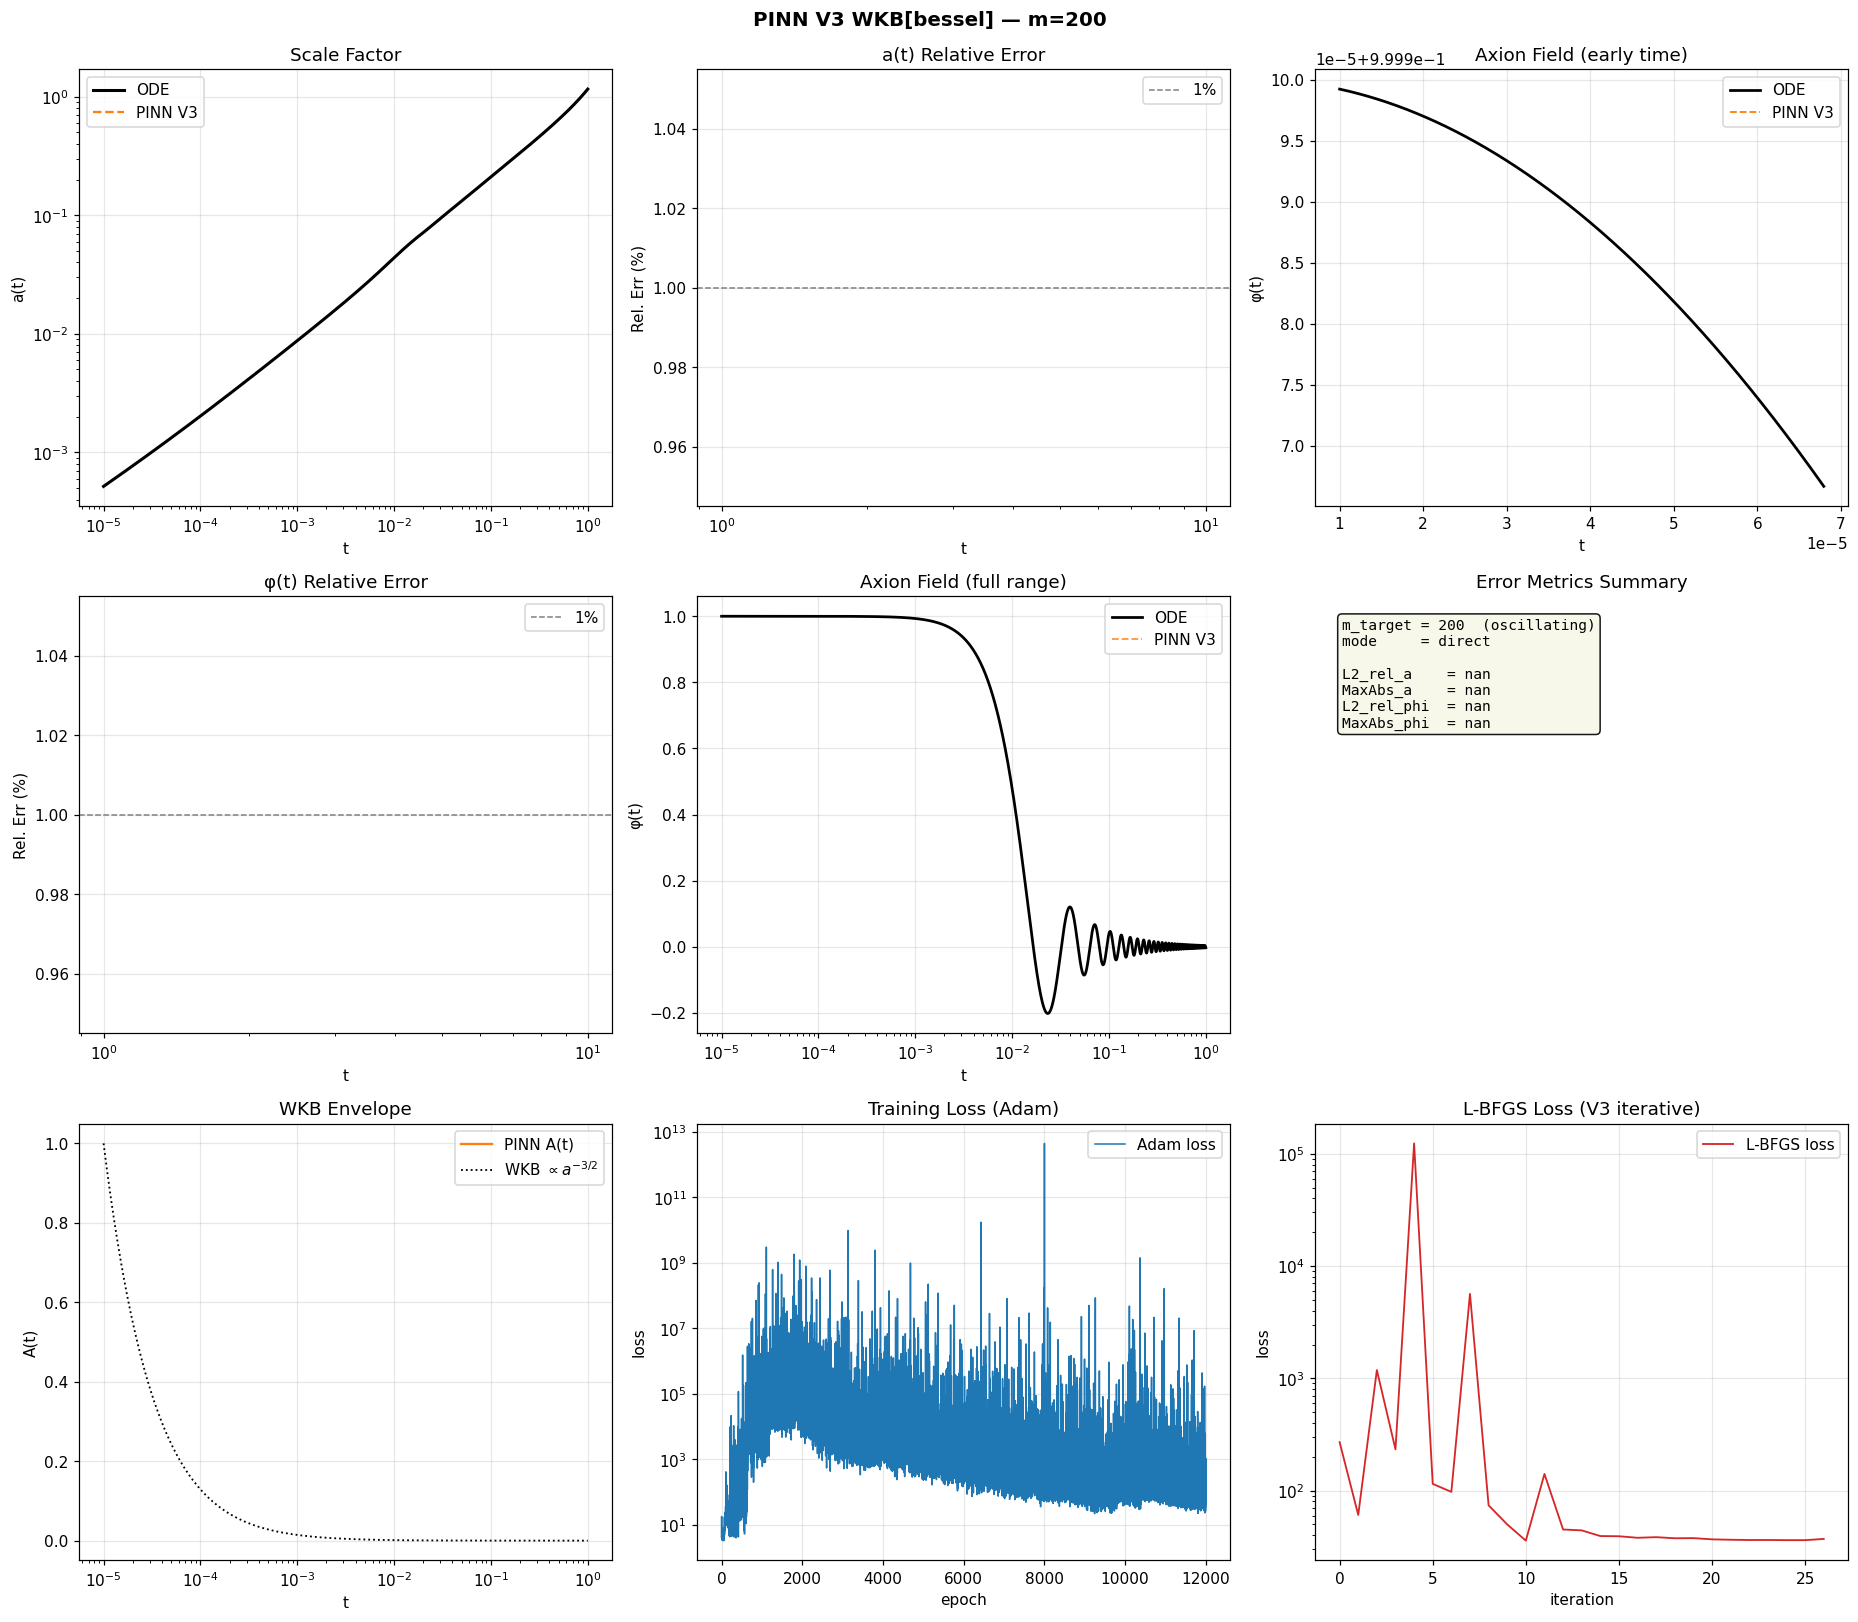

Saved → results_v3/m2e2_v3.png


In [15]:
print('=' * 62)
print('  EXPERIMENT A: WKB PINN V3   m = 200')
print('  V2 baseline: L2(a)=10.3x, L2(phi)=1.12x (terrible)')
print('=' * 62)

res_A = run_wkb_v3(
    m_target            = 200.0,
    phi0                = 1.0,
    a0                  = A_IN,
    t_end               = T_FI,
    # Network
    n_harmonics         = 6,        # sin/cos(k·m·t) for k=1..6
    hidden_phi          = 192,
    depth_phi           = 4,
    # Training
    adam_epochs         = 12000,
    adam_lr             = 3e-4,
    warmup_epochs       = 600,
    lbfgs_outer         = 15,
    lbfgs_inner         = 100,
    pretrain_a_epochs   = 1500,
    pretrain_phi_epochs = 500,
    n_colloc            = 5000,
    causal_eps_start    = 1.0,
    causal_eps_end      = 10.0,
    causal_warmup       = 4000,
    use_pcgrad          = True,
    use_rar             = True,
    print_every         = 2000,
)

## 16. Experiment B — m = 50 (Onset Regime, V3 baseline check)

  EXPERIMENT B: WKB PINN V3   m = 50 (onset)
──────────────────────────────────────────────────────────
  m_target=50  regime=oscillating  mode=direct
  N_osc(physical)=7.96e+00  |  a_osc=2.389e-02
──────────────────────────────────────────────────────────

Solving ODE reference ...
ODE: 0.07s  success=True  nfev=5186

WKB PINN V3 [bessel]  params=146,187

── Phase 0a: Pretrain a_net (fit ODE reference) ──────────────
    a_net pretrain [   0] log-MSE=3.715e+01
    a_net pretrain [ 500] log-MSE=5.794e-02
  a_net pretrain done → final log-MSE=2.021e-02

── Phase 0b: WKB phi_net pretrain ───────────────────────────
  WKB phi_net pretrain: 400 ep → final=6.894e-01

── Phase 1: Adam (8000 ep)  causal_ε: 1.0→8.0  PCGrad=True  RAR=True ──
  [    0] loss=1.015e+01  lF=8.974e+00  lKG=1.174e+00  ε=1.0  cr=0.71  N=4000  lr=1.00e-06
  [ 2000] loss=2.797e+06  lF=2.796e+06  lKG=7.558e+02  ε=8.0  cr=0.69  N=4400  lr=2.74e-04
  [ 4000] loss=6.466e+05  lF=6.464e+05  lKG=2.210e+02  ε=8.0  cr=0.69  N=48

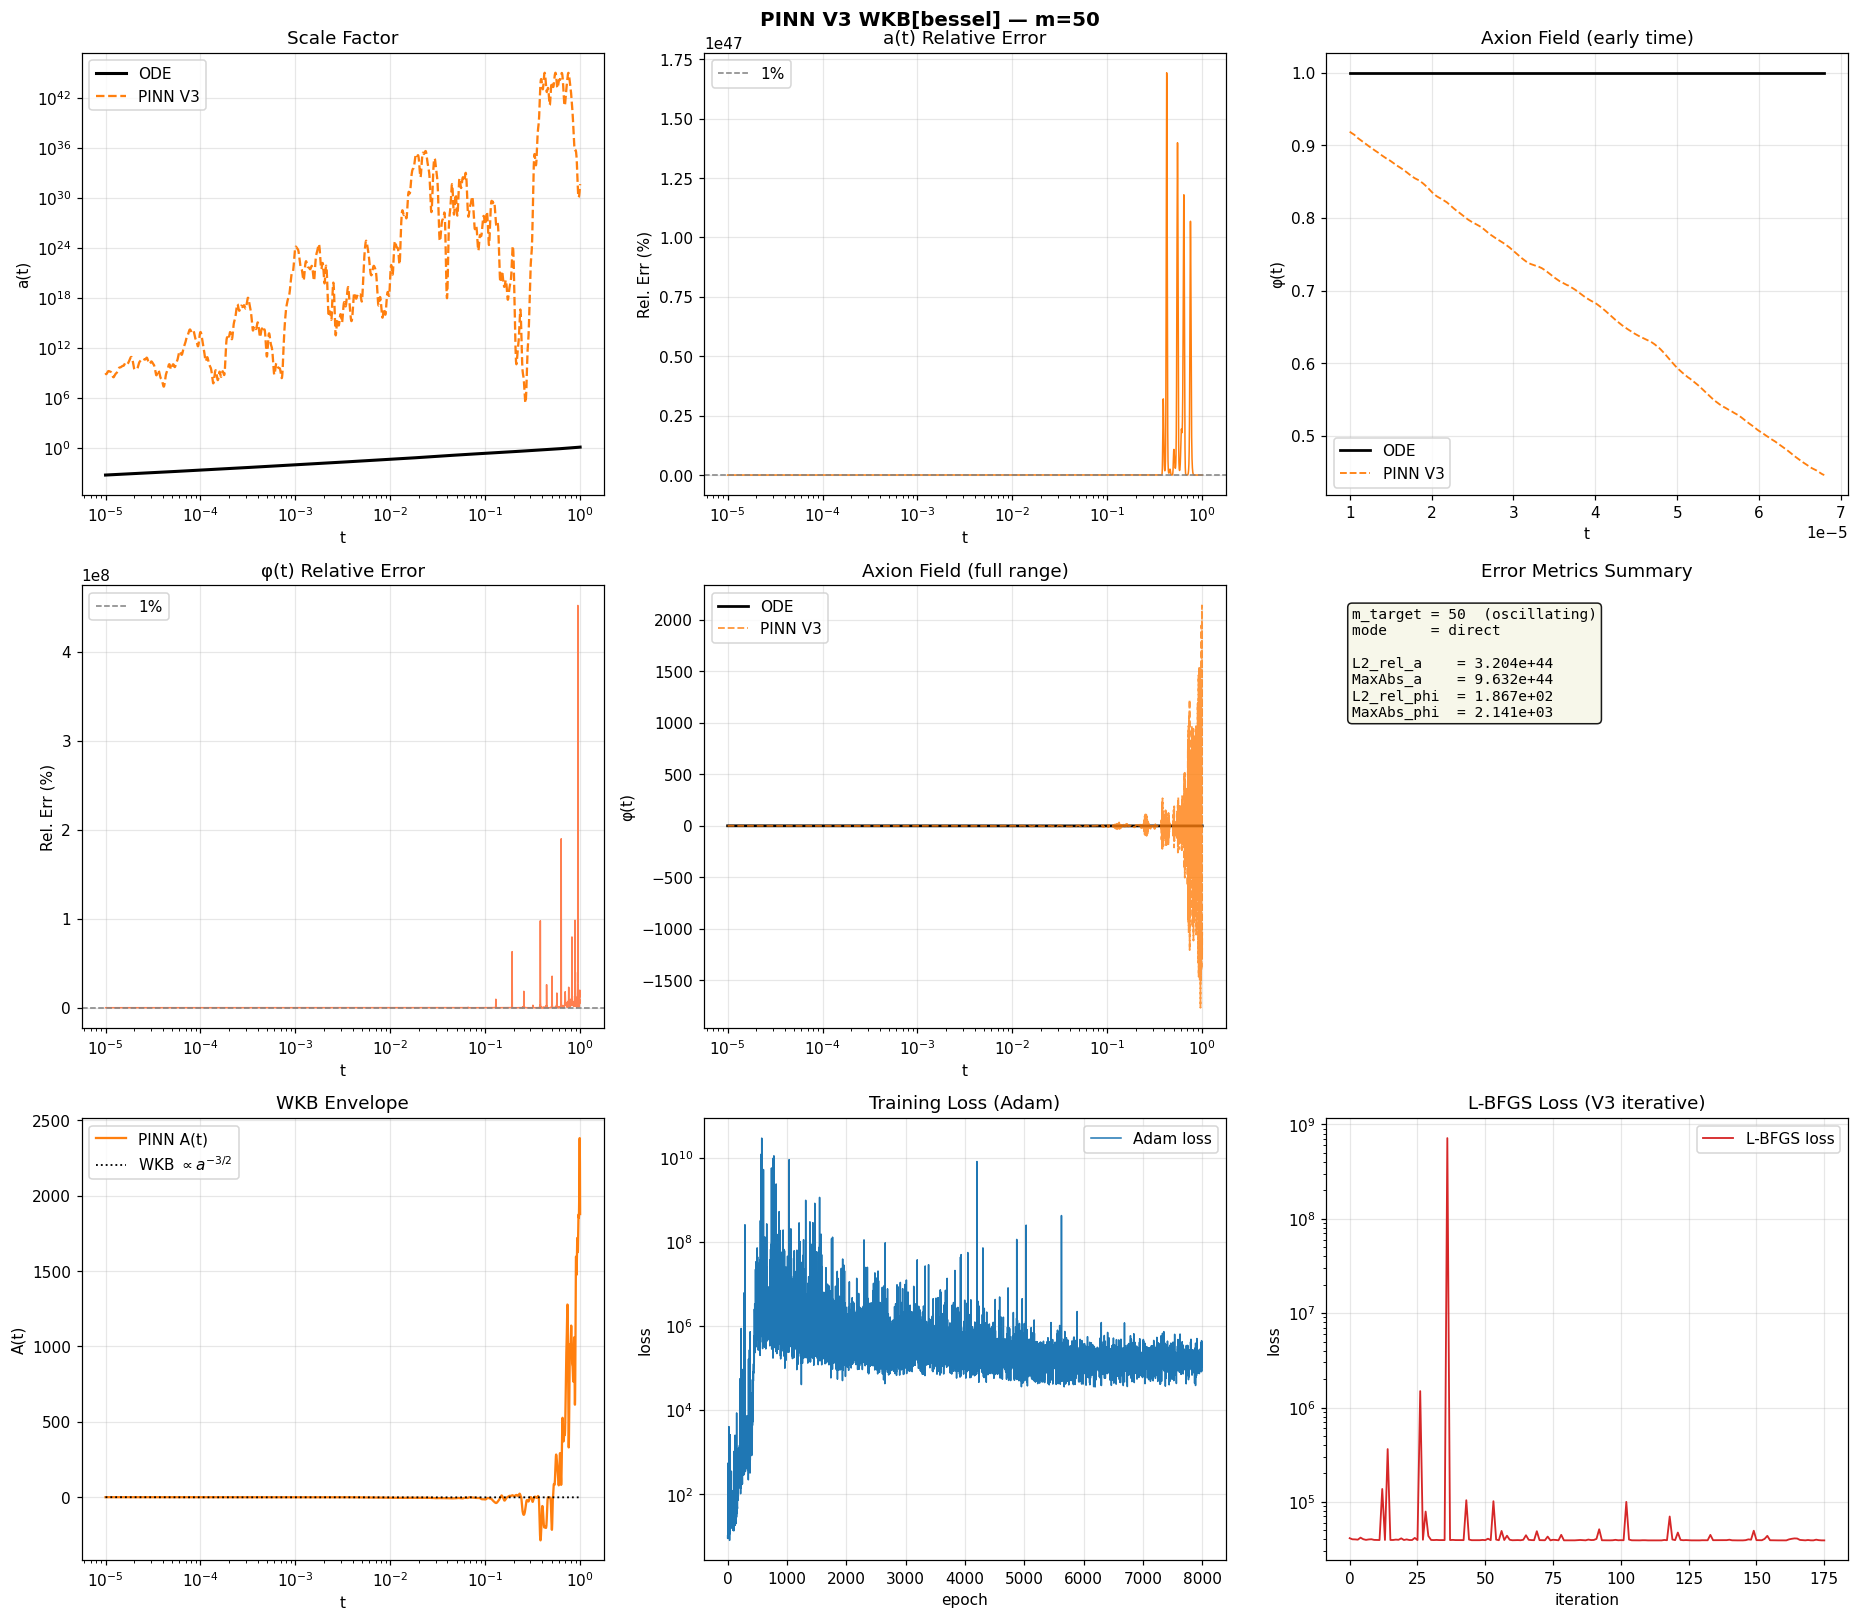

Saved → results_v3/m5e1_v3.png


In [16]:
print('=' * 62)
print('  EXPERIMENT B: WKB PINN V3   m = 50 (onset)')
print('=' * 62)

res_B = run_wkb_v3(
    m_target            = 50.0,
    phi0                = 1.0,
    n_harmonics         = 4,
    hidden_phi          = 128,
    depth_phi           = 3,
    adam_epochs         = 8000,
    pretrain_a_epochs   = 1000,
    pretrain_phi_epochs = 400,
    causal_eps_start    = 1.0,
    causal_eps_end      = 8.0,
    causal_warmup       = 2000,
    n_colloc            = 4000,
)

## 17. Experiment C — m = 200, VoP Ansatz (Bessel basis)

ทดสอบ **Variation of Parameters** approach:
- φ(t) = C1(t)·j0(mt) + C2(t)·y0(mt)
- C1, C2 เป็น slowly varying functions → ควร converge เร็วกว่า WKB
- เปรียบเทียบ VoP vs WKB[bessel] vs V2

  EXPERIMENT C: VoP PINN V3   m = 200
  Ansatz: φ = C1(t)·j0(mt) + C2(t)·y0(mt)
──────────────────────────────────────────────────────────
  m_target=200  regime=oscillating  mode=direct
  N_osc(physical)=3.18e+01  |  a_osc=1.194e-02
──────────────────────────────────────────────────────────

Solving ODE reference ...
ODE: 0.17s  success=True  nfev=14084

VoP PINN V3  params=141,067

── Phase 0a: Pretrain a_net (fit ODE reference) ──────────────
    a_net pretrain [   0] log-MSE=4.702e+01
    a_net pretrain [ 500] log-MSE=4.079e-02
    a_net pretrain [1000] log-MSE=1.157e-02
  a_net pretrain done → final log-MSE=7.999e-03

── Phase 1: Adam (12000 ep)  causal_ε: 1.0→10.0  PCGrad=True  RAR=True ──
  [    0] loss=6.566e+00  lF=6.380e+00  lKG=1.865e-01  ε=1.0  cr=0.42  N=5000  lr=1.00e-06
  [ 2000] loss=2.328e+00  lF=1.794e+00  lKG=5.340e-01  ε=5.5  cr=0.54  N=5400  lr=2.89e-04
  [ 4000] loss=2.894e+00  lF=2.202e+00  lKG=6.914e-01  ε=10.0  cr=0.54  N=5800  lr=2.39e-04
  [ 6000] loss=3.171e

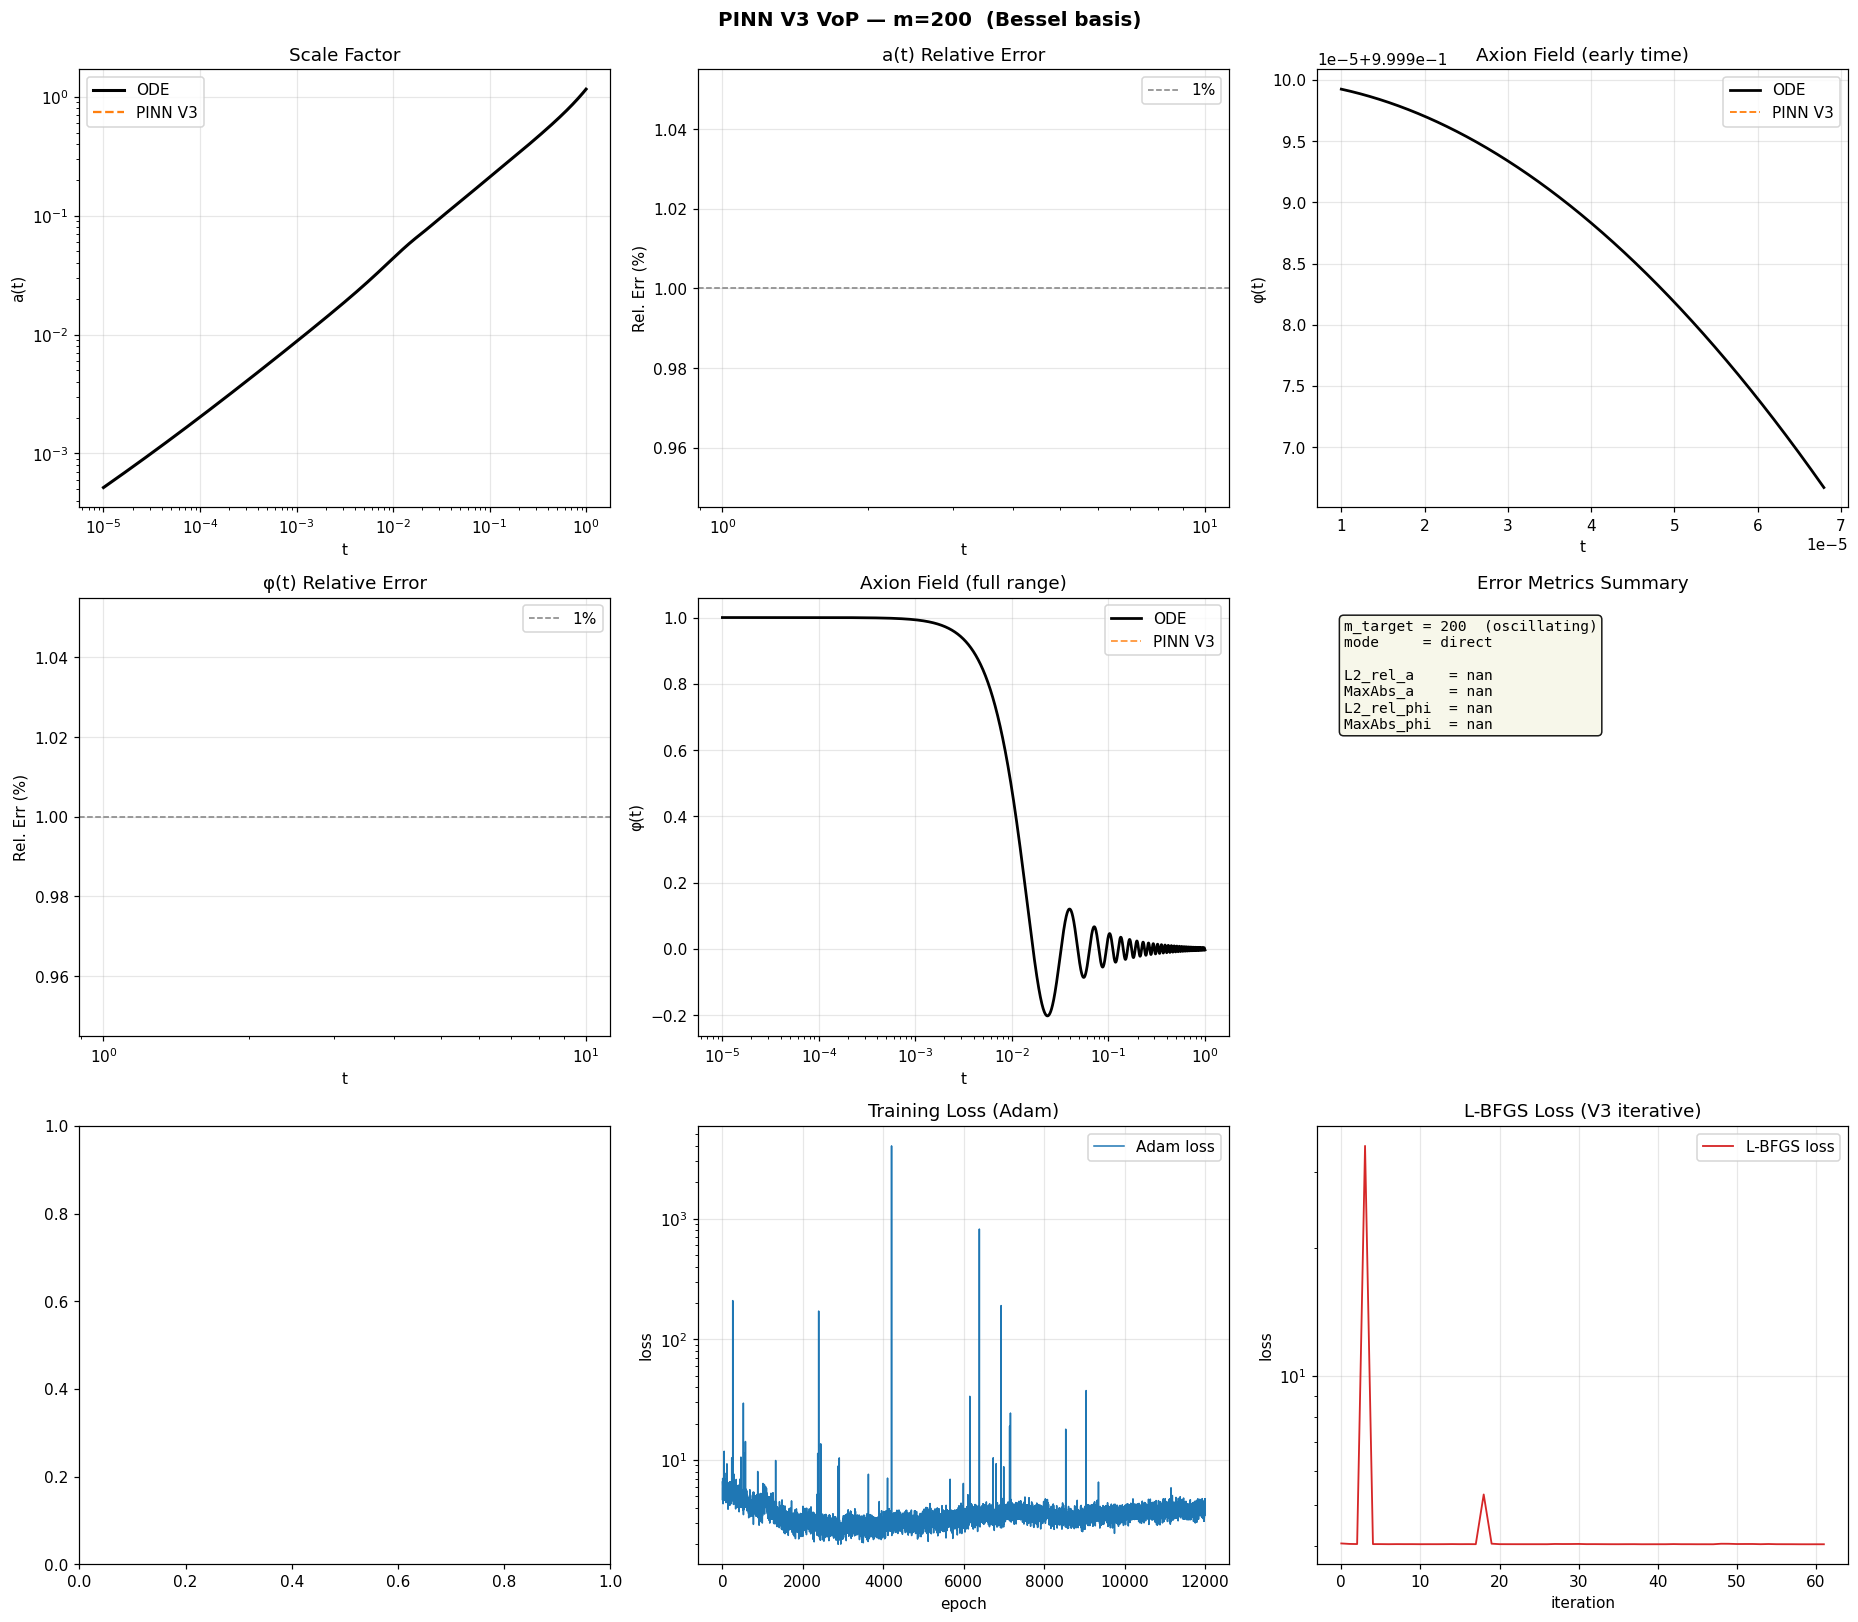

Saved → results_v3/m2e2_v3.png


In [17]:
print('=' * 62)
print('  EXPERIMENT C: VoP PINN V3   m = 200')
print('  Ansatz: φ = C1(t)·j0(mt) + C2(t)·y0(mt)')
print('=' * 62)

res_C = run_vop_v3(
    m_target            = 200.0,
    phi0                = 1.0,
    n_bessel            = 4,     # j0(kmt), y0(kmt) for k=1..4
    hidden_phi          = 128,   # smaller — C1,C2 are slowly varying
    depth_phi           = 3,
    adam_epochs         = 12000,
    adam_lr             = 3e-4,
    warmup_epochs       = 600,
    lbfgs_outer         = 15,
    lbfgs_inner         = 100,
    pretrain_a_epochs   = 1500,
    n_colloc            = 5000,
    causal_eps_start    = 1.0,
    causal_eps_end      = 10.0,
    causal_warmup       = 4000,
    use_pcgrad          = True,
    use_rar             = True,
    print_every         = 2000,
)

## 17b. Experiment D — m = 200, EXACT VoP (image formula)

ทดสอบ **Exact Variation of Parameters** ansatz ตรงกับสูตรในภาพ:

phi(t) = a(t)^{-3/2} * sqrt(t/t_i) * [C1(t)*J_{1/2}(m*t) + C2(t)*Y_{1/2}(m*t)]

- J_{1/2}(x) = sin(x)/sqrt(x),  Y_{1/2}(x) = -cos(x)/sqrt(x)  — exact Bessel order n=1/2 (matter dom)
- a(t)^{-3/2}: WKB amplitude envelope (energy density ~ a^{-3})
- (t/t_i)^{1/2}: exact matching ให้ KG equation เป็น Bessel equation order n=1/2
- C1, C2 เป็น slowly-varying → near-constant ใน matter dom → network เรียนได้ง่ายมาก
- ใช้ ExactVoPPINN จาก Section 6: chains a_net(t) → detach → phi_net(t, a_detached)

In [18]:
print('=' * 70)
print('  EXPERIMENT D: EXACT VoP PINN V3   m = 200')
print('  Ansatz (image formula):')
print('    phi = a^{-3/2} * sqrt(t/t_i) * [C1*J_{1/2}(mt) + C2*Y_{1/2}(mt)]')
print('  ExactVoPPINN: a_net -> detach -> phi_net with exact Bessel prefix')
print('=' * 70)

res_D = run_exact_vop_v3(
    m_target            = 200.0,
    phi0                = 1.0,
    a0                  = A_IN,
    n_bessel            = 4,      # J_{1/2}(kmt), Y_{1/2}(kmt)  k=1..4
    hidden_phi          = 128,    # C1,C2 are nearly constant → small network OK
    depth_phi           = 3,
    adam_epochs         = 12000,
    adam_lr             = 3e-4,
    warmup_epochs       = 600,
    lbfgs_outer         = 15,
    lbfgs_inner         = 100,
    pretrain_a_epochs   = 1500,
    n_colloc            = 5000,
    causal_eps_start    = 1.0,
    causal_eps_end      = 10.0,
    causal_warmup       = 4000,
    use_pcgrad          = True,
    use_rar             = True,
    print_every         = 2000,
)

  EXPERIMENT D: EXACT VoP PINN V3   m = 200
  Ansatz (image formula):
    phi = a^{-3/2} * sqrt(t/t_i) * [C1*J_{1/2}(mt) + C2*Y_{1/2}(mt)]
  ExactVoPPINN: a_net -> detach -> phi_net with exact Bessel prefix
──────────────────────────────────────────────────────────
  m_target=200  regime=oscillating  mode=direct
  N_osc(physical)=3.18e+01  |  a_osc=1.194e-02
──────────────────────────────────────────────────────────

Solving ODE reference ...
ODE: 0.18s  success=True  nfev=14084

Exact VoP PINN V3  params=141,067
  Ansatz: a^(-3/2) * sqrt(t/t_i) * [C1*J_{1/2}(mt) + C2*Y_{1/2}(mt)]

── Phase 0a: Pretrain a_net (fit ODE reference) ──────────────
    a_net pretrain [   0] log-MSE=3.856e+01
    a_net pretrain [ 500] log-MSE=6.100e-02
    a_net pretrain [1000] log-MSE=1.458e-02
  a_net pretrain done → final log-MSE=8.666e-03

── Phase 1: Adam (12000 ep)  causal_ε: 1.0→10.0  PCGrad=True  RAR=True ──
  [    0] loss=4.121e+02  lF=4.362e+00  lKG=4.077e+02  ε=1.0  cr=0.32  N=5000  lr=1.00e-06
  

NotImplementedError: Module [ExactVoPFieldNet_V3] is missing the required "forward" function

## 18. V3 Full Summary — WKB vs VoP vs V2

In [ ]:
print('=' * 75)
print('  PINN V3 — FULL RESULTS SUMMARY')
print('=' * 75)
print(f'  {"Method":<38}  {"L2(a)":>10}  {"L2(phi)":>10}  Pass?')
print('-' * 75)

# V2 baseline (from saved result m2e2_v2.png)
print(f'  {"V2 WKB (OscillatoryEmb, no pretrain)":<38}'
      f'  {"1.036e+01":>10}  {"1.123e+00":>10}  X')

for label, res in [
    ('V3 WKB [bessel]  m=200', 'res_A'),
    ('V3 WKB [bessel]  m=50',  'res_B'),
    ('V3 VoP (approx)  m=200', 'res_C'),
    ('V3 VoP (exact)   m=200', 'res_D'),
]:
    try:
        r  = eval(res)
    except NameError:
        print(f'  {label:<38}  {"(not run)":>10}  {"(not run)":>10}')
        continue
    if r is None:
        continue
    m  = r['eval']['metrics']
    La, Lp = m['L2_a'], m['L2_phi']
    ok = ('OK' if La < 0.05 and Lp < 0.5
          else ('~' if La < 0.2 else 'X'))
    print(f'  {label:<38}  {La:>10.3e}  {Lp:>10.3e}  {ok}')

print('=' * 75)
print()
print('Ansatz progression:')
print()
print('  A. WKB:           phi = A(t) * cos(m*t + dPhi(t))')
print('     Features: BesselEmb J_{1/2}/Y_{1/2} — 1/sqrt(t) decay built in')
print()
print('  B. Approx VoP:    phi = C1(t)*j0(mt) + C2(t)*y0(mt)')
print('     j0=sin(mt)/(mt), y0=-cos(mt)/(mt) — matter-dom exact solution')
print()
print('  C. Exact VoP:     phi = a^{-3/2} * sqrt(t/t_i) * [C1*J_{1/2}+C2*Y_{1/2}]')
print('     J_{1/2}(x)=sin(x)/sqrt(x),  Y_{1/2}(x)=-cos(x)/sqrt(x)')
print('     Matches image formula exactly (n=1/2 Bessel, matter dom order)')
print('     a^{-3/2} from ExactVoPPINN chains: a_net -> detach -> phi_net')
print()
print('Bessel order theory:')
print('  KG in matter dom: ddot_phi + (2/t)*dot_phi + m^2*phi = 0')
print('  Substitute phi = t^{-1/2} * f(mt):')
print('  => f"(x) + (1 - 1/4 / x^2) f(x) = 0  [x=mt]')
print('  => Bessel equation, order n = 1/2  (n^2 = 1/4)')
print('  => f = C1*J_{1/2}(mt) + C2*Y_{1/2}(mt)')
print('  => phi = t^{-1/2} * [C1*J_{1/2}(mt) + C2*Y_{1/2}(mt)]')
print('  With a ~ t^{2/3}: a^{-3/2} ~ t^{-1}, so a^{-3/2}*sqrt(t) ~ t^{-1/2}  QED')